# EDA Notebook

**This a test for EDA on my Horse Racing Predictor, the plan is to use EDA, to find crucial features for building a TabNet horse racing predictor.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr


### Basic Setup

In [2]:
# Load data
df = pd.read_csv("merged_horse_racing_data.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (106250, 33)
Columns: ['track_name', 'race_date', 'race_time', 'going', 'distance', 'horse_name', 'jockey', 'claims', 'trainer', 'race_position', 'lost_by_length', 'age', 'weight', 'rating', 'first_place_found', 'batch_number', 'url_index_in_batch', 'source_file', 'race_position_clean', 'lost_by_length_clean', 'rating_clean', 'weight_clean', 'track_name_clean', 'race_date_clean', 'race_time_clean', 'going_clean', 'distance_clean', 'horse_name_clean', 'jockey_clean', 'trainer_clean', 'claims_clean', 'age_clean', 'first_place_found_clean']


### Checking Correlation basic values and the horses position
Loading + Checking of Data. Guaranteeing contuity + no errors

In [3]:
# Check if data is loaded properly
if df.empty:
    print("Warning: DataFrame is empty! Check your CSV file path and contents.")
else:
    print(f"Data loaded successfully with {len(df)} rows")

# Basic data info
print("\n=== Dataset Overview ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum().sort_values(ascending=False))

Data loaded successfully with 106250 rows

=== Dataset Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106250 entries, 0 to 106249
Data columns (total 33 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   track_name               80094 non-null   object 
 1   race_date                0 non-null       float64
 2   race_time                106250 non-null  object 
 3   going                    106060 non-null  object 
 4   distance                 106243 non-null  object 
 5   horse_name               106250 non-null  object 
 6   jockey                   106221 non-null  object 
 7   claims                   106250 non-null  int64  
 8   trainer                  106250 non-null  object 
 9   race_position            106210 non-null  object 
 10  lost_by_length           86038 non-null   object 
 11  age                      106250 non-null  int64  
 12  weight                   106250 non-null  obje

### Stupid Sanity Checks:
familarization with Dataset.

In [4]:
target = 'race_position_clean'
count = 0  
filtered_df = df[df[target] == 1]
print(filtered_df.head(3))

                                      track_name  race_date race_time  \
8   Curragh Racing Results | 1st June 2022 17:10        NaN     17:10   
13  Curragh Racing Results | 1st June 2022 17:45        NaN     17:45   
27  Curragh Racing Results | 1st June 2022 18:15        NaN     18:15   

                            going distance          horse_name       jockey  \
8                    Good  (Turf)       7f        Crypto Force  C. T. Keane   
13                           Good       6f  Age of Kings (IRE)   Ryan Moore   
27  Good (Good To Firm In Places)    1m 4f       Fennela (IRE)  Shane Foley   

    claims            trainer race_position  ... race_date_clean  \
8        0  M. D. O'Callaghan           1st  ...         Unknown   
13       0      Aidan O'Brien           1st  ...         Unknown   
27       0  Mrs J. Harrington           1st  ...         Unknown   

    race_time_clean                    going_clean distance_clean  \
8             17:10                   Good  (Tur

## Logarithmic Plots for basic numeric values.


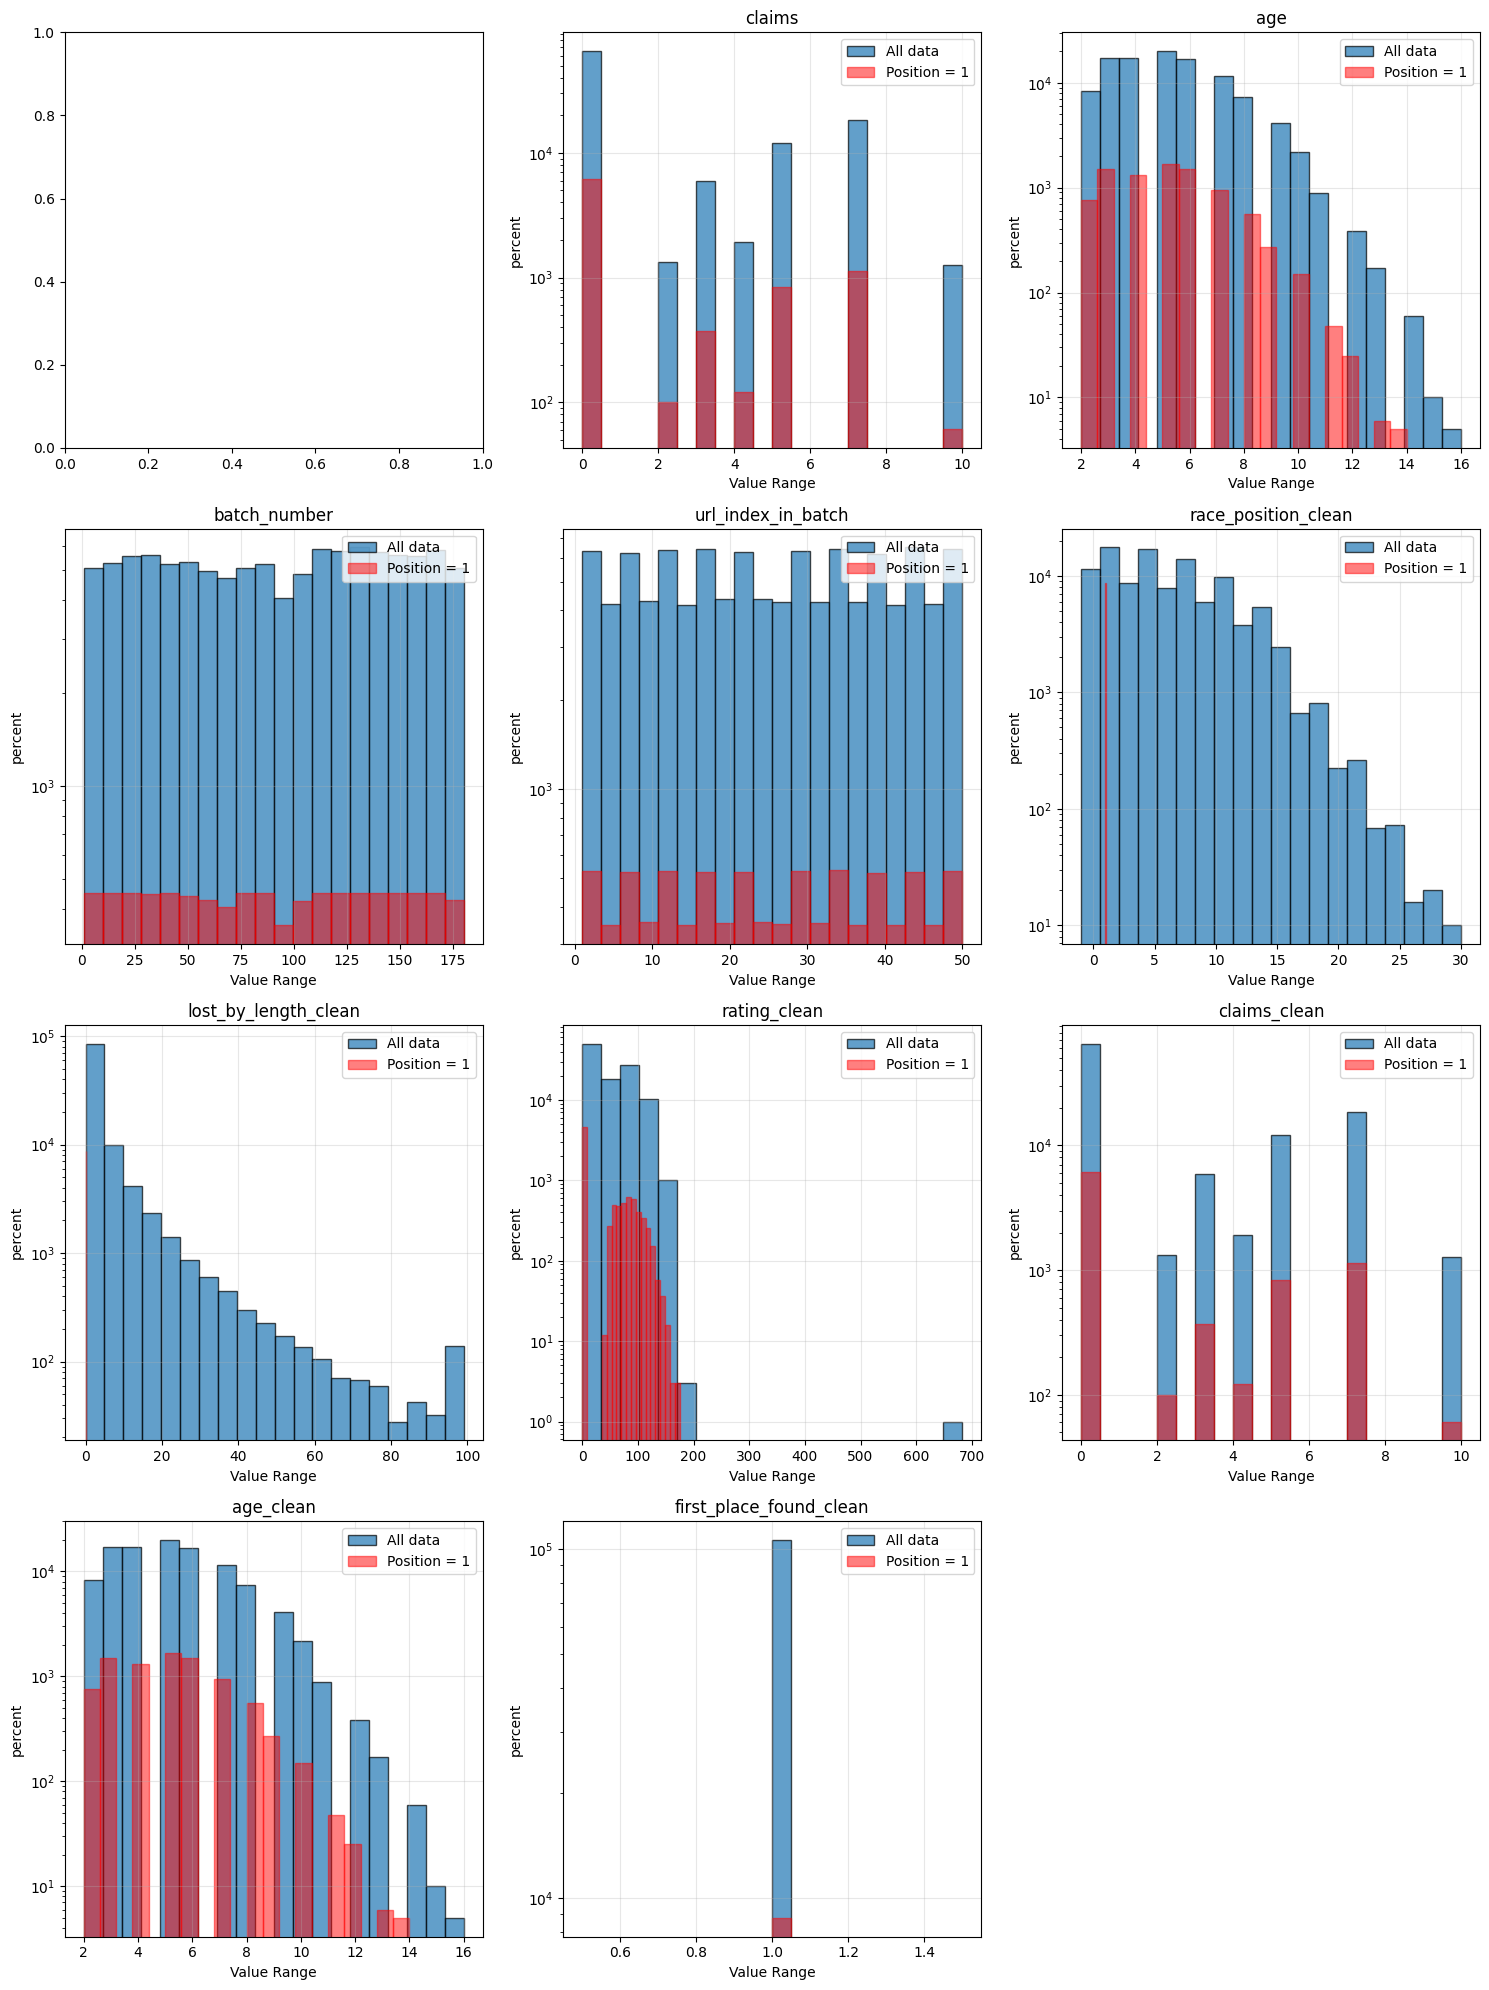

In [5]:

# Filter for numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n = len(numeric_cols)

# Create subplots
fig, axes = plt.subplots(nrows=(n+2)//3, ncols=3, figsize=(15, 5*((n+2)//3)))
axes = axes.flatten() if n > 1 else [axes]

# Plot distribution for each numeric column
for i, col in enumerate(numeric_cols):
   data = df[col].dropna()
   data_winners = df[df[target] == 1][col].dropna()
   
   if len(data) > 0:
       axes[i].hist(data, bins=20, alpha=0.7, edgecolor='black', label='All data')
       
       if len(data_winners) > 0:
           axes[i].hist(data_winners, bins=20, alpha=0.5, edgecolor='red', 
                       color='red', label='Position = 1')
       
       axes[i].set_title(f'{col}')
       axes[i].set_xlabel('Value Range')
       axes[i].set_ylabel('percent')
       axes[i].set_yscale('log')
       axes[i].legend()
       axes[i].grid(True, alpha=0.3)

# Hide empty subplots
for j in range(n, len(axes)):
   axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Jockey Specific Variables Declarations.
**The idea is to basically develop a new DF with key features for jockey and trainer specific variables then derive key insights into the data with this.**

In [29]:
#Keep Dataset Clear with Jockey/Trainer Specific one.
df_jt = df.copy()

#Function to Clean Names:
def clean_names(name):
    if not isinstance(name, str):
        return name
    
    name = name.replace('.', '').strip()
    parts = name.split()
    
    if len(parts) < 2:
        return name.title()
    
    initials = [p[0].upper() + '.' for p in parts[:-1]]
    
    # Keep last name as-is (preserves apostrophes, caps)
    last_name = parts[-1]
    
    return ' '.join(initials + [last_name])

import pandas as pd
from datetime import datetime
import re

def parse_time_date(track_name):
    """
    Parse time and date from track name format: 'Track Name | Date Time'
    Returns standardized datetime or None if parsing fails
    """
    if not isinstance(track_name, str) or '|' not in track_name:
        return None
    
    try:
        # Split by | and get the date/time part
        time_date_part = track_name.split('|')[1].strip()
        
        # Common date patterns to handle
        patterns = [
            r'(\d{1,2}(?:st|nd|rd|th)?\s+\w+\s+\d{4})\s+(\d{1,2}:\d{2})',  # "1st June 2022 17:10"
            r'(\d{1,2}/\d{1,2}/\d{4})\s+(\d{1,2}:\d{2})',                   # "06/01/2022 17:10"
            r'(\d{4}-\d{2}-\d{2})\s+(\d{1,2}:\d{2})',                       # "2022-06-01 17:10"
            r'(\w+\s+\d{1,2},?\s+\d{4})\s+(\d{1,2}:\d{2})',                # "June 1, 2022 17:10"
        ]
        
        for pattern in patterns:
            match = re.search(pattern, time_date_part)
            if match:
                date_part, time_part = match.groups()
                
                # Clean up ordinal indicators (1st, 2nd, etc.)
                date_part = re.sub(r'(\d+)(?:st|nd|rd|th)', r'\1', date_part)
                
                # Try different date formats
                date_formats = [
                    '%d %B %Y',      # "1 June 2022"
                    '%d/%m/%Y',      # "01/06/2022"
                    '%m/%d/%Y',      # "06/01/2022" 
                    '%Y-%m-%d',      # "2022-06-01"
                    '%B %d %Y',      # "June 1 2022"
                    '%B %d, %Y',     # "June 1, 2022"
                ]
                
                for date_format in date_formats:
                    try:
                        # Parse date and time separately, then combine
                        date_obj = datetime.strptime(date_part.strip(), date_format)
                        time_obj = datetime.strptime(time_part.strip(), '%H:%M').time()
                        
                        # Combine date and time
                        full_datetime = datetime.combine(date_obj.date(), time_obj)
                        return full_datetime
                    except ValueError:
                        continue
        
        return None
        
    except Exception:
        return None

"""
============================================================
        Name Cleaning for Tracks + Jockeys + Trainers. 
============================================================

            VERY IMPORTANT!!! USE IN ML TOO 

"""
df_jt['J_Name'] = df_jt['jockey'].apply(clean_names).str.replace('.','', regex=False)
df_jt['T_Name'] = df_jt['trainer'].apply(clean_names).str.replace('.','', regex=False)

# Updated track processing
df_jt['track_stripped'] = df_jt['track_name'].str.split('|').str[0].str.strip()
df_jt['time_date'] = df_jt['track_name'].apply(parse_time_date)
df['time_date'] = df['track_name'].apply(parse_time_date)
# Drop rows where time_date parsing failed (NaN values)
print(f"Rows before dropping NaN time_date: {len(df_jt)}")
df_jt = df_jt.dropna(subset=['time_date'])
print(f"Rows after dropping NaN time_date: {len(df_jt)}")

print("=" * 30)
print("Track Examples:")
print(df_jt['track_stripped'].head(3))
print("=" * 30)
print("Time/Date Examples:")
print(df_jt['time_date'].head(3))
print("=" * 30)
print("Original track_name vs parsed:")
print(df_jt[['track_name', 'track_stripped', 'time_date']].head(3))
print("=" * 30)
print(df_jt['J_Name'].head(3))
print("=" * 30)
print(df_jt['T_Name'].head(3))
print("=" * 30)

# Merge Jockey + Trainer
df_jt['j_t'] = df_jt['J_Name'].astype(str) + " | " + df_jt['T_Name'].astype(str)
print(df_jt['j_t'].head(3))
print("=" * 30)

# Calculate JT Wins
# Calculate JT Wins (actual wins only)
jtw = df_jt[df_jt[target] == 1].groupby('j_t').size().reset_index(name='jt_wins')
print(jtw.sort_values('jt_wins', ascending=False).head(3))
print("=" * 30)
df_jt = df_jt.merge(jtw, on='j_t', how='left')

# Fill missing values (if any combos have zero wins)
df_jt['jt_wins'] = df_jt['jt_wins'].fillna(0).astype(int)

# Calculate Total JT Runs
# value_counts = df_jt['j_t'].value_counts()
jt_summary = df_jt['j_t'].value_counts().reset_index()
jt_summary.columns = ['j_t', 'jt_runs']
df_jt = df_jt.merge(jt_summary, on='j_t', how='left')
print("=" * 30)
print("StandAlone Runs for JT")
print("=" * 30)
print(df_jt['jt_runs'].head(3))
print("=" * 30)
print("De-Duplicated + sorted JT runs + JT combo")
print("=" * 30)
print(df_jt[['j_t', 'jt_runs']].drop_duplicates().sort_values('jt_runs', ascending=False).head(3))
print("=" * 30)

# Additional time-based features for EDA
df_jt['race_hour'] = df_jt['time_date'].dt.hour
df_jt['race_day_of_week'] = df_jt['time_date'].dt.day_name()
df_jt['race_month'] = df_jt['time_date'].dt.month
df_jt['race_year'] = df_jt['time_date'].dt.year

print("Time-based features created:")
print("Race hours distribution:")
print(df_jt['race_hour'].value_counts().sort_index().head())
print("=" * 30)
print("Race days distribution:")
print(df_jt['race_day_of_week'].value_counts())
print("=" * 30)

"""Outcome = 9+ cleaned columns ready for handling + new DataFrame. 
new cols = {j_t, jt_wins, J_Name, T_Name, track_stripped, jt_runs, time_date, race_hour, race_day_of_week, race_month, race_year}"""

Rows before dropping NaN time_date: 106250
Rows after dropping NaN time_date: 80094
Track Examples:
0    Curragh Racing Results
1    Curragh Racing Results
2    Curragh Racing Results
Name: track_stripped, dtype: object
Time/Date Examples:
0   2022-06-01 17:10:00
1   2022-06-01 17:10:00
2   2022-06-01 17:10:00
Name: time_date, dtype: datetime64[ns]
Original track_name vs parsed:
                                     track_name          track_stripped  \
0  Curragh Racing Results | 1st June 2022 17:10  Curragh Racing Results   
1  Curragh Racing Results | 1st June 2022 17:10  Curragh Racing Results   
2  Curragh Racing Results | 1st June 2022 17:10  Curragh Racing Results   

            time_date  
0 2022-06-01 17:10:00  
1 2022-06-01 17:10:00  
2 2022-06-01 17:10:00  
0    D W O'Connor
1        G M Ryan
2         W J Lee
Name: J_Name, dtype: object
0    D J English
1    D A O'Brien
2     A McIntyre
Name: T_Name, dtype: object
0    D W O'Connor | D J English
1        G M Ryan | D A O'Br

'Outcome = 9+ cleaned columns ready for handling + new DataFrame. \nnew cols = {j_t, jt_wins, J_Name, T_Name, track_stripped, jt_runs, time_date, race_hour, race_day_of_week, race_month, race_year}'

Converting numeric columns...
Converted race_position_clean to numeric. NaN count: 0
Converted lost_by_length_clean to numeric. NaN count: 0
Converted rating_clean to numeric. NaN count: 0
Converted weight_clean to numeric. NaN count: 80094
Converted distance_clean to numeric. NaN count: 80094
Converted age_clean to numeric. NaN count: 0
Detecting conditioning runs...
Detecting class/distance changes...
Detecting jockey changes...
Analyzing layoff patterns...
Analyzing weight/age patterns...


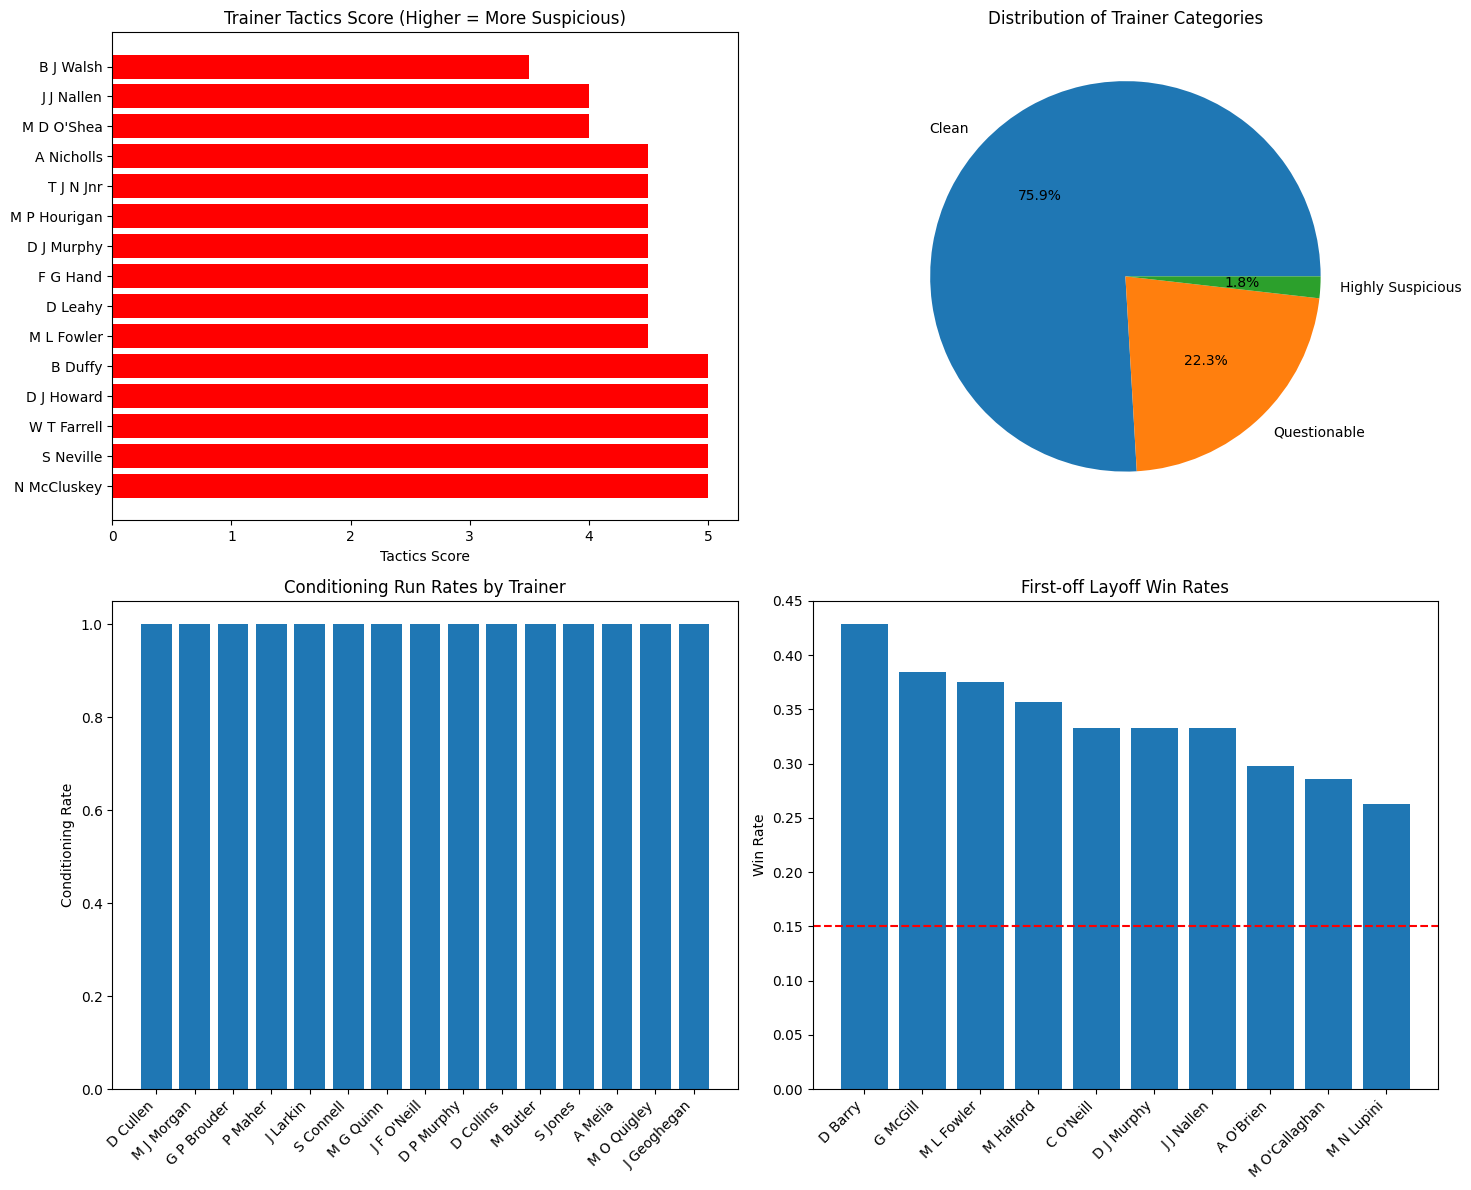


=== TRAINER TACTICS SUMMARY ===

Total trainers analyzed: 835

Tactics category breakdown:
tactics_category
Clean                634
Questionable         186
Highly Suspicious     15
Name: count, dtype: int64


Top 15 Most Suspicious Trainers:
           T_Name  tactics_score  conditioning_rate  manipulation_rate  jockey_switch_rate   tactics_category
289   N McCluskey            5.0           0.250000           0.000000            0.764706  Highly Suspicious
326     S Neville            5.0           0.375000           0.111111            0.680000  Highly Suspicious
380   W T Farrell            5.0           0.333333           0.000000            0.695652  Highly Suspicious
646    D J Howard            5.0           1.000000           0.000000            0.760000  Highly Suspicious
760       B Duffy            5.0           0.250000           0.000000            0.952381  Highly Suspicious
111    M L Fowler            4.5           0.100000           0.500000            0.714286  Hig

In [7]:
# Trainer Tactics and Pattern Detection System
# Adjusted for available horse racing data columns

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# First, let's create the target variable from race_position_clean
def create_target_variable(df_jt):
    """Create winner column from race position"""
    df_jt['winner'] = (df_jt['race_position_clean'] == 1).astype(int)
    return df_jt

# Data type conversion helper
def convert_numeric_columns(df_jt):
    """Convert string columns to numeric where needed"""
    numeric_columns = [
        'race_position_clean', 'lost_by_length_clean', 'rating_clean', 
        'weight_clean', 'distance_clean', 'age_clean'
    ]
    
    for col in numeric_columns:
        if col in df_jt.columns:
            # Convert to numeric, replacing non-numeric values with NaN
            df_jt[col] = pd.to_numeric(df_jt[col], errors='coerce')
            print(f"Converted {col} to numeric. NaN count: {df_jt[col].isna().sum()}")
    
    return df_jt

# 1. Conditioning Runs Detection
def detect_conditioning_runs(df_jt, target='winner'):
    """
    Detect patterns of poor runs followed by sudden wins
    Using available data: race_position_clean, lost_by_length_clean
    """
    # Sort by horse and race date/time
    df_jt = df_jt.sort_values(['horse_name_clean', 'time_date'])
    
    # Calculate previous race performance
    df_jt['prev_position'] = df_jt.groupby('horse_name_clean')['race_position_clean'].shift(1)
    df_jt['prev_beaten_lengths'] = df_jt.groupby('horse_name_clean')['lost_by_length_clean'].shift(1)
    df_jt['prev_win'] = df_jt.groupby('horse_name_clean')[target].shift(1)
    
    # Days since last race
    df_jt['prev_date'] = df_jt.groupby('horse_name_clean')['time_date'].shift(1)
    df_jt['days_since_last'] = (df_jt['time_date'] - df_jt['prev_date']).dt.days
    
    # Identify poor last run (finished 5th or worse, or beaten by 10+ lengths)
    df_jt['poor_last_run'] = (
        (df_jt['prev_position'] >= 5) | 
        (df_jt['prev_beaten_lengths'] >= 10)
    ).astype(int)
    
    # Conditioning pattern: poor recent form + sudden win
    df_jt['conditioning_win'] = (
        (df_jt[target] == 1) & 
        (df_jt['poor_last_run'] == 1) &
        (df_jt['days_since_last'] <= 30)
    ).astype(int)
    
    # Calculate trainer conditioning patterns
    trainer_conditioning = df_jt.groupby('T_Name').agg({
        'conditioning_win': 'sum',
        target: 'sum',
        'horse_name_clean': 'count'
    }).reset_index()
    
    trainer_conditioning['conditioning_rate'] = (
        trainer_conditioning['conditioning_win'] / trainer_conditioning[target]
    ).fillna(0)
    
    trainer_conditioning = trainer_conditioning.rename(columns={'horse_name_clean': 'total_runs'})
    
    # Flag suspicious trainers
    threshold = trainer_conditioning['conditioning_rate'].quantile(0.8)
    trainer_conditioning['suspicious_conditioning'] = (
        (trainer_conditioning['conditioning_rate'] > threshold) & 
        (trainer_conditioning['total_runs'] >= 20)
    ).astype(int)
    
    return df_jt, trainer_conditioning

# 2. Class/Distance Manipulation Detection
def detect_class_distance_changes(df_jt, target='winner'):
    """
    Detect suspicious distance changes and rating drops
    Using: distance_clean, rating_clean
    """
    df_jt = df_jt.sort_values(['horse_name_clean', 'time_date'])
    
    # Calculate distance changes
    if 'distance_clean' in df_jt.columns and df_jt['distance_clean'].notna().any():
        df_jt['prev_distance'] = df_jt.groupby('horse_name_clean')['distance_clean'].shift(1)
        # Only calculate where both values exist
        mask = df_jt['distance_clean'].notna() & df_jt['prev_distance'].notna()
        df_jt['distance_change'] = np.nan
        df_jt.loc[mask, 'distance_change'] = abs(
            df_jt.loc[mask, 'distance_clean'] - df_jt.loc[mask, 'prev_distance']
        )
        df_jt['significant_distance_change'] = (df_jt['distance_change'] >= 4).astype(int)
    else:
        df_jt['distance_change'] = np.nan
        df_jt['significant_distance_change'] = 0
    
    # Rating drops (if rating represents class level)
    if 'rating_clean' in df_jt.columns and df_jt['rating_clean'].notna().any():
        df_jt['prev_rating'] = df_jt.groupby('horse_name_clean')['rating_clean'].shift(1)
        # Only calculate where both values exist
        mask = df_jt['rating_clean'].notna() & df_jt['prev_rating'].notna()
        df_jt['rating_drop'] = np.nan
        df_jt.loc[mask, 'rating_drop'] = df_jt.loc[mask, 'prev_rating'] - df_jt.loc[mask, 'rating_clean']
        df_jt['significant_rating_drop'] = (df_jt['rating_drop'] >= 10).astype(int)
    else:
        df_jt['rating_drop'] = np.nan
        df_jt['significant_rating_drop'] = 0
    
    # Going changes
    df_jt['prev_going'] = df_jt.groupby('horse_name_clean')['going_clean'].shift(1)
    df_jt['going_change'] = (df_jt['going_clean'] != df_jt['prev_going']).astype(int)
    
    # Suspicious pattern: significant changes + win
    df_jt['suspicious_class_drop'] = (
        ((df_jt['significant_distance_change'] == 1) | 
         (df_jt['significant_rating_drop'] == 1)) & 
        (df_jt[target] == 1)
    ).astype(int)
    
    # Trainer patterns
    trainer_class_patterns = df_jt.groupby('T_Name').agg({
        'suspicious_class_drop': 'sum',
        'significant_rating_drop': 'sum',
        'significant_distance_change': 'sum',
        target: 'sum'
    }).reset_index()
    
    trainer_class_patterns['manipulation_rate'] = (
        trainer_class_patterns['suspicious_class_drop'] / 
        (trainer_class_patterns['significant_rating_drop'] + 
         trainer_class_patterns['significant_distance_change'])
    ).fillna(0)
    
    return df_jt, trainer_class_patterns

# 3. Jockey Change Patterns
def detect_jockey_changes(df_jt, target='winner'):
    """
    Detect patterns in jockey switching
    """
    df_jt = df_jt.sort_values(['horse_name_clean', 'time_date'])
    
    # Track jockey changes
    df_jt['prev_jockey'] = df_jt.groupby('horse_name_clean')['J_Name'].shift(1)
    df_jt['jockey_change'] = (df_jt['J_Name'] != df_jt['prev_jockey']).astype(int)
    
    # Identify apprentice/claiming jockeys
    df_jt['has_claim'] = df_jt['claims_clean'].notna().astype(int)
    df_jt['prev_had_claim'] = df_jt.groupby('horse_name_clean')['has_claim'].shift(1)
    
    # Suspicious pattern: switch from regular to claiming jockey
    df_jt['claim_switch'] = (
        (df_jt['jockey_change'] == 1) & 
        (df_jt['has_claim'] == 1) & 
        (df_jt['prev_had_claim'] == 0)
    ).astype(int)
    
    # Calculate jockey win rates
    jockey_stats = df_jt.groupby('J_Name')[target].agg(['sum', 'count', 'mean']).reset_index()
    
    # Only create quality categories if we have data
    if len(jockey_stats) > 0 and jockey_stats['mean'].notna().any():
        try:
            jockey_stats['jockey_quality'] = pd.qcut(
                jockey_stats['mean'], 
                q=[0, 0.33, 0.67, 1.0], 
                labels=['low', 'mid', 'high'],
                duplicates='drop'
            )
        except:
            # If qcut fails, use a simple threshold approach
            mean_rate = jockey_stats['mean'].mean()
            jockey_stats['jockey_quality'] = pd.cut(
                jockey_stats['mean'],
                bins=[-np.inf, mean_rate*0.8, mean_rate*1.2, np.inf],
                labels=['low', 'mid', 'high']
            )
    else:
        jockey_stats['jockey_quality'] = 'unknown'
    
    df_jt = df_jt.merge(jockey_stats[['J_Name', 'jockey_quality']], on='J_Name', how='left')
    
    # Trainer jockey switching patterns
    trainer_jockey_patterns = df_jt.groupby('T_Name').agg({
        'jockey_change': 'sum',
        'claim_switch': 'sum',
        'horse_name_clean': 'count'
    }).reset_index()
    
    trainer_jockey_patterns['jockey_switch_rate'] = (
        trainer_jockey_patterns['jockey_change'] / 
        trainer_jockey_patterns['horse_name_clean']
    ).fillna(0)
    
    return df_jt, trainer_jockey_patterns

# 4. Layoff Win Analysis
def analyze_layoff_wins(df_jt, target='winner'):
    """
    Analyze trainer patterns with horses returning from layoffs
    """
    # Already have days_since_last from conditioning runs
    if 'days_since_last' not in df_jt.columns:
        df_jt = df_jt.sort_values(['horse_name_clean', 'time_date'])
        df_jt['prev_date'] = df_jt.groupby('horse_name_clean')['time_date'].shift(1)
        df_jt['days_since_last'] = (df_jt['time_date'] - df_jt['prev_date']).dt.days
    
    # Define layoff categories
    if df_jt['days_since_last'].notna().any():
        df_jt['layoff_category'] = pd.cut(
            df_jt['days_since_last'],
            bins=[0, 30, 60, 90, 180, 365, np.inf],
            labels=['fresh', 'short', 'medium', 'long', 'very_long', 'extreme'],
            include_lowest=True
        )
    else:
        df_jt['layoff_category'] = 'unknown'
    
    # First run back after layoff (60+ days)
    df_jt['first_off_layoff'] = (
        (df_jt['days_since_last'] >= 60) & 
        (df_jt['days_since_last'].notna())
    ).astype(int)
    
    # Second run back
    df_jt['prev_layoff'] = df_jt.groupby('horse_name_clean')['first_off_layoff'].shift(1)
    df_jt['second_off_layoff'] = (
        (df_jt['prev_layoff'] == 1) & 
        (df_jt['days_since_last'] <= 30)
    ).astype(int)
    
    # Calculate trainer layoff patterns
    trainer_layoff = pd.DataFrame()
    
    # First off layoff wins
    first_off = df_jt[df_jt['first_off_layoff'] == 1].groupby('T_Name').agg({
        target: ['sum', 'count']
    })
    first_off.columns = ['first_off_wins', 'first_off_runs']
    first_off['first_off_win_rate'] = first_off['first_off_wins'] / first_off['first_off_runs']
    
    # Second off layoff wins
    second_off = df_jt[df_jt['second_off_layoff'] == 1].groupby('T_Name').agg({
        target: ['sum', 'count']
    })
    second_off.columns = ['second_off_wins', 'second_off_runs']
    second_off['second_off_win_rate'] = second_off['second_off_wins'] / second_off['second_off_runs']
    
    # Combine
    trainer_layoff = pd.concat([first_off, second_off], axis=1).fillna(0)
    
    # Flag suspicious layoff patterns
    trainer_layoff['suspicious_layoff_pattern'] = (
        (trainer_layoff['first_off_win_rate'] > 0.25) | 
        (trainer_layoff['second_off_win_rate'] > 0.30)
    ).astype(int)
    
    return df_jt, trainer_layoff.reset_index()

# 5. Weight and Age Patterns (additional analysis with available data)
def analyze_weight_age_patterns(df_jt, target='winner'):
    """
    Analyze patterns with weight changes and age groups
    """
    df_jt = df_jt.sort_values(['horse_name_clean', 'time_date'])
    
    # Weight changes
    if 'weight_clean' in df_jt.columns:
        df_jt['prev_weight'] = df_jt.groupby('horse_name_clean')['weight_clean'].shift(1)
        # Only calculate weight change if both values are numeric
        mask = df_jt['weight_clean'].notna() & df_jt['prev_weight'].notna()
        df_jt['weight_change'] = np.nan
        df_jt.loc[mask, 'weight_change'] = df_jt.loc[mask, 'weight_clean'] - df_jt.loc[mask, 'prev_weight']
        df_jt['significant_weight_drop'] = (df_jt['weight_change'] <= -5).astype(int)
    else:
        df_jt['weight_change'] = np.nan
        df_jt['significant_weight_drop'] = 0
    
    # Age categories
    if 'age_clean' in df_jt.columns and df_jt['age_clean'].notna().any():
        # Check the range of ages
        min_age = df_jt['age_clean'].min()
        max_age = df_jt['age_clean'].max()
        
        # Adjust bins if needed
        if min_age >= 0 and max_age <= 20:
            df_jt['age_category'] = pd.cut(
                df_jt['age_clean'],
                bins=[0, 3, 5, 8, 20],
                labels=['young', 'prime', 'experienced', 'veteran'],
                include_lowest=True
            )
        else:
            # Use quartiles for unexpected age ranges
            df_jt['age_category'] = pd.qcut(
                df_jt['age_clean'],
                q=4,
                labels=['Q1', 'Q2', 'Q3', 'Q4'],
                duplicates='drop'
            )
    else:
        df_jt['age_category'] = 'unknown'
    
    # Trainer patterns by age
    trainer_age_patterns = df_jt.groupby(['T_Name', 'age_category'])[target].agg(['sum', 'count', 'mean']).reset_index()
    trainer_age_patterns.columns = ['T_Name', 'age_category', 'wins', 'runs', 'win_rate']
    
    return df_jt, trainer_age_patterns

# 6. Comprehensive Trainer Tactics Score
def calculate_trainer_tactics_score(df_jt, target='winner'):
    """
    Calculate overall suspicious tactics score for each trainer
    """
    # Create target variable if not exists
    if target not in df_jt.columns:
        df_jt = create_target_variable(df_jt)
    
    # Run all detection functions
    print("Detecting conditioning runs...")
    df_jt, conditioning = detect_conditioning_runs(df_jt, target)
    
    print("Detecting class/distance changes...")
    df_jt, class_changes = detect_class_distance_changes(df_jt, target)
    
    print("Detecting jockey changes...")
    df_jt, jockey_changes = detect_jockey_changes(df_jt, target)
    
    print("Analyzing layoff patterns...")
    df_jt, layoffs = analyze_layoff_wins(df_jt, target)
    
    print("Analyzing weight/age patterns...")
    df_jt, age_patterns = analyze_weight_age_patterns(df_jt, target)
    
    # Combine all suspicious indicators
    tactics_summary = pd.DataFrame({'T_Name': df_jt['T_Name'].unique()})
    
    # Merge all pattern scores
    tactics_summary = tactics_summary.merge(
        conditioning[['T_Name', 'conditioning_rate', 'suspicious_conditioning']], 
        on='T_Name', how='left'
    )
    
    tactics_summary = tactics_summary.merge(
        class_changes[['T_Name', 'manipulation_rate']], 
        on='T_Name', how='left'
    )
    
    tactics_summary = tactics_summary.merge(
        jockey_changes[['T_Name', 'jockey_switch_rate']], 
        on='T_Name', how='left'
    )
    
    tactics_summary = tactics_summary.merge(
        layoffs[['T_Name', 'suspicious_layoff_pattern']], 
        on='T_Name', how='left'
    )
    
    # Calculate overall tactics score
    tactics_summary['tactics_score'] = (
        tactics_summary['suspicious_conditioning'].fillna(0) * 2 +
        (tactics_summary['manipulation_rate'].fillna(0) > 0.4).astype(int) * 1.5 +
        (tactics_summary['jockey_switch_rate'].fillna(0) > 0.5).astype(int) +
        tactics_summary['suspicious_layoff_pattern'].fillna(0) * 2
    )
    
    # Categorize trainers - check if we have valid scores
    if len(tactics_summary) > 0 and tactics_summary['tactics_score'].notna().any():
        # Check score range
        min_score = tactics_summary['tactics_score'].min()
        max_score = tactics_summary['tactics_score'].max()
        
        if max_score > 0:  # Only categorize if we have non-zero scores
            tactics_summary['tactics_category'] = pd.cut(
                tactics_summary['tactics_score'],
                bins=[-0.1, 1, 3, max(10, max_score + 0.1)],
                labels=['Clean', 'Questionable', 'Highly Suspicious'],
                include_lowest=True
            )
        else:
            # All scores are 0
            tactics_summary['tactics_category'] = 'Clean'
    else:
        tactics_summary['tactics_category'] = 'Clean'
    
    # Add to main dataframe
    df_jt = df_jt.merge(
        tactics_summary[['T_Name', 'tactics_score', 'tactics_category']], 
        on='T_Name', how='left'
    )
    
    return df_jt, tactics_summary

# 7. Feature Engineering for ML
def create_tactics_features(df_jt):
    """
    Create ML-ready features based on trainer tactics
    """
    # List of features created
    ml_features = [
        'winner',
        'poor_last_run',
        'conditioning_win',
        'days_since_last',
        'first_off_layoff',
        'second_off_layoff',
        'jockey_change',
        'has_claim',
        'claim_switch',
        'distance_change',
        'significant_distance_change',
        'rating_drop',
        'significant_rating_drop',
        'going_change',
        'suspicious_class_drop',
        'weight_change',
        'significant_weight_drop',
        'tactics_score'
    ]
    
    # Create interaction features
    df_jt['layoff_x_tactics'] = df_jt['first_off_layoff'] * df_jt['tactics_score']
    df_jt['rating_drop_x_tactics'] = df_jt['rating_drop'] * df_jt['tactics_score']
    df_jt['jockey_change_x_tactics'] = df_jt['jockey_change'] * df_jt['tactics_score']
    
    ml_features.extend(['layoff_x_tactics', 'rating_drop_x_tactics', 'jockey_change_x_tactics'])
    
    # Ensure all features exist
    available_features = [f for f in ml_features if f in df_jt.columns]
    
    return df_jt, available_features

# 8. Visualization
def visualize_trainer_tactics(tactics_summary, df_jt, top_n=15):
    """
    Visualize trainer tactics patterns
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Top suspicious trainers
    ax1 = axes[0, 0]
    top_suspicious = tactics_summary.nlargest(top_n, 'tactics_score')
    colors = ['red' if x > 3 else 'orange' if x > 1 else 'green' for x in top_suspicious['tactics_score']]
    ax1.barh(top_suspicious['T_Name'], top_suspicious['tactics_score'], color=colors)
    ax1.set_title('Trainer Tactics Score (Higher = More Suspicious)')
    ax1.set_xlabel('Tactics Score')
    
    # Tactics category distribution
    ax2 = axes[0, 1]
    category_counts = tactics_summary['tactics_category'].value_counts()
    ax2.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%')
    ax2.set_title('Distribution of Trainer Categories')
    
    # Conditioning patterns
    ax3 = axes[1, 0]
    conditioning_data = tactics_summary.nlargest(top_n, 'conditioning_rate')
    ax3.bar(range(len(conditioning_data)), conditioning_data['conditioning_rate'])
    ax3.set_xticks(range(len(conditioning_data)))
    ax3.set_xticklabels(conditioning_data['T_Name'], rotation=45, ha='right')
    ax3.set_title('Conditioning Run Rates by Trainer')
    ax3.set_ylabel('Conditioning Rate')
    
    # Layoff win rates
    ax4 = axes[1, 1]
    layoff_data = df_jt.groupby('T_Name').agg({
        'first_off_layoff': 'sum',
        'winner': 'sum'
    })
    layoff_data = layoff_data[layoff_data['first_off_layoff'] >= 5]  # Min 5 layoff runs
    layoff_data['layoff_win_rate'] = (
        df_jt[df_jt['first_off_layoff'] == 1].groupby('T_Name')['winner'].sum() / 
        layoff_data['first_off_layoff']
    )
    top_layoff = layoff_data.nlargest(10, 'layoff_win_rate')
    
    ax4.bar(range(len(top_layoff)), top_layoff['layoff_win_rate'])
    ax4.set_xticks(range(len(top_layoff)))
    ax4.set_xticklabels(top_layoff.index, rotation=45, ha='right')
    ax4.set_title('First-off Layoff Win Rates')
    ax4.set_ylabel('Win Rate')
    ax4.axhline(y=0.15, color='r', linestyle='--', label='Normal Rate')
    
    plt.tight_layout()
    plt.show()

# Main execution function
def analyze_trainer_tactics(df_jt):
    """
    Complete trainer tactics analysis
    """
    # Convert numeric columns first
    print("Converting numeric columns...")
    df_jt = convert_numeric_columns(df_jt)
    
    # Ensure we have the processed names
    if 'J_Name' not in df_jt.columns or 'T_Name' not in df_jt.columns:
        print("Processing jockey and trainer names...")
        # Assuming the name cleaning from your original code
        df_jt['J_Name'] = df_jt['jockey_clean']
        df_jt['T_Name'] = df_jt['trainer_clean']
    
    # Ensure we have time_date
    if 'time_date' not in df_jt.columns:
        print("Creating time_date from race_date_clean and race_time_clean...")
        df_jt['time_date'] = pd.to_datetime(
            df_jt['race_date_clean'].astype(str) + ' ' + df_jt['race_time_clean'].astype(str),
            errors='coerce'
        )
    
    # Calculate all tactics
    df_jt, tactics_summary = calculate_trainer_tactics_score(df_jt, 'winner')
    
    # Create ML features
    df_jt, ml_features = create_tactics_features(df_jt)
    
    # Visualize results
    visualize_trainer_tactics(tactics_summary, df_jt)
    
    # Print summary statistics
    print("\n=== TRAINER TACTICS SUMMARY ===")
    print(f"\nTotal trainers analyzed: {len(tactics_summary)}")
    print(f"\nTactics category breakdown:")
    print(tactics_summary['tactics_category'].value_counts())
    
    print("\n\nTop 15 Most Suspicious Trainers:")
    print(tactics_summary.nlargest(15, 'tactics_score')[
        ['T_Name', 'tactics_score', 'conditioning_rate', 'manipulation_rate', 
         'jockey_switch_rate', 'tactics_category']
    ].to_string())
    
    print(f"\n\nML Features created: {len(ml_features)}")
    print("Features:", ml_features)
    
    # Feature importance hint
    if 'winner' in df_jt.columns:
        print("\nKey feature correlations with winning:")
        feature_cols = [f for f in ml_features if f in df_jt.columns and f != 'winner']
        # Only calculate correlations for numeric features
        numeric_features = []
        for f in feature_cols:
            if df_jt[f].dtype in ['float64', 'int64', 'int32', 'float32']:
                numeric_features.append(f)
        
        if numeric_features:
            correlations = df_jt[numeric_features + ['winner']].corr()['winner'].sort_values(ascending=False)
            print(correlations.head(10))
    
    return df_jt, tactics_summary, ml_features

# Example usage:
# Run the complete analysis
df_jt, tactics_summary, ml_features = analyze_trainer_tactics(df_jt)

# Save the enhanced dataframe if needed
# df_jt.to_csv('enhanced_racing_data_with_tactics.csv', index=False)

# Save tactics summary for reference
# tactics_summary.to_csv('trainer_tactics_summary.csv', index=False)

In [8]:
import numpy as np

print(df_jt.head(0))

def wilson_score(wins, total, confidence=0.95):
    if total == 0:
        return 0.0
    z = {0.95: 1.96, 0.99: 2.576, 0.90: 1.645}[confidence]
    phat = wins / total
    denominator = 1 + z**2 / total
    centre = phat + z**2 / (2 * total)
    margin = z * np.sqrt((phat * (1 - phat) + z**2 / (4 * total)) / total)
    return (centre - margin) / denominator

df_jt['wilson_score'] = df_jt.apply(
    lambda row: wilson_score(row['jt_wins'], row['jt_runs']),
    axis=1
)
wilson_score_df = df_jt[['j_t', 'wilson_score']].drop_duplicates().reset_index(drop=True)


print(df_jt[['j_t','wilson_score', 'jt_runs', 'jt_wins']].drop_duplicates().sort_values('wilson_score' , ascending=False).head(60))


Empty DataFrame
Columns: [track_name, race_date, race_time, going, distance, horse_name, jockey, claims, trainer, race_position, lost_by_length, age, weight, rating, first_place_found, batch_number, url_index_in_batch, source_file, race_position_clean, lost_by_length_clean, rating_clean, weight_clean, track_name_clean, race_date_clean, race_time_clean, going_clean, distance_clean, horse_name_clean, jockey_clean, trainer_clean, claims_clean, age_clean, first_place_found_clean, J_Name, T_Name, track_stripped, time_date, j_t, jt_wins, jt_runs, race_hour, race_day_of_week, race_month, race_year, winner, prev_position, prev_beaten_lengths, prev_win, prev_date, days_since_last, poor_last_run, conditioning_win, distance_change, significant_distance_change, prev_rating, rating_drop, significant_rating_drop, prev_going, going_change, suspicious_class_drop, prev_jockey, jockey_change, has_claim, prev_had_claim, claim_switch, jockey_quality, layoff_category, first_off_layoff, prev_layoff, second_

Now with eveyrhting Created, it's time to plot and draw comparisons between the data to see if we can learn anything.


In [9]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import re

df = pd.read_csv('merged_horse_racing_data.csv')

# First, ensure you have the binary target column
target = 'race_position_clean'  # This should already be 1 for winners, higher for others

# If race_position_clean is actually position (1st, 2nd, etc.), create binary target:
df_jt['is_winner'] = (df_jt['race_position_clean'] == 1).astype(int)
target = 'is_winner'

wilson_cols = wilson_score_df.columns.drop('j_t').tolist()



# Now calculate correlations
cols = ["jt_wins", "jt_runs", "wilson_score", 
         ]

print(f"Correlations with {target} (1=winner, 0=non-winner):\n")

for col in cols:
    try:
        # Ensure numeric data
        x = pd.to_numeric(df_jt[col], errors='coerce')
        y = df_jt[target]  # Already binary
        
        # Remove NaN values
        valid = x.notna() & y.notna()
        
        if valid.sum() < 2:
            print(f"Skipping {col}: not enough valid data.")
            continue
        
        # Calculate correlation
        corr, p_value = pearsonr(x[valid], y[valid])
        
        print(f"Column: {col}")
        print(f"Pearson Correlation: {corr:.3f}")
        print(f"P-value: {p_value:.3g}")
        print("-" * 40)
        
    except Exception as e:
        print(f"Error processing {col}: {e}\n")

# Also check the distribution of your target
print(f"\nTarget distribution:")
print(f"Winners (1): {df_jt[target].sum()} ({df_jt[target].mean():.1%})")
print(f"Non-winners (0): {(df_jt[target] == 0).sum()}")



Correlations with is_winner (1=winner, 0=non-winner):

Column: jt_wins
Pearson Correlation: 0.151
P-value: 0
----------------------------------------
Column: jt_runs
Pearson Correlation: 0.096
P-value: 8.5e-163
----------------------------------------
Column: wilson_score
Pearson Correlation: 0.316
P-value: 0
----------------------------------------

Target distribution:
Winners (1): 6558 (8.2%)
Non-winners (0): 73536


### Develop a Track + Going + Distance DataFrame and use it to gain deep profound insights.
_track = df. 

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import re

df = pd.read_csv('merged_horse_racing_data.csv')

_track = df.copy()

_track['track_stripped'] = _track['track_name'].str.split('Racing Results').str[0].str.strip()

_track['going'] = _track['going'].str.split('(').str[0].str.strip()

GOING_SCALE = [
    "Firm",
    "Good to Firm",
    "Good",
    "Good to Yielding",
    "Yielding",
    "Yielding to Soft",
    "Soft",
    "Soft to Heavy",
    "Heavy",
    "Standard"
]

def extract_clean_going(raw_going):
    if not isinstance(raw_going, str):
        return None

    raw = raw_going.lower().replace('-', ' ').strip()

    # First: check for multi-word exact matches
    for going in sorted(GOING_SCALE, key=lambda g: -len(g)):  # Longest first
        pattern = r'\b' + re.escape(going.lower()) + r'\b'
        if re.search(pattern, raw):
            return going

    # If no match: split and check individual words
    tokens = re.findall(r'\b\w+\b', raw)  # split on word boundaries
    for token in tokens:
        for going in GOING_SCALE:
            if token == going.lower():
                return going  # return first match

    return None


_track['going'] = _track['going'].apply(extract_clean_going)

import pandas as pd
import scipy.stats as stats

def ensure_label(_track):
    """
    Create binary label = 1 if horse won (position == '1st'), else 0.
    """
    if 'label' not in _track.columns:
        # adjust the condition if your position column is named differently
        _track['label'] = (_track['race_position_clean'] == 1).astype(int)
    return _track

def add_performance_on_going(_track):
    """
    Adds performance_on_{going_type} features based on historical win rate per going.
    """
    # make sure label exists
    _track = ensure_label(_track)
    
    if 'going' in _track.columns and 'horse_name' in _track.columns:
        for going_type in _track['going'].dropna().unique():
            going_mask = _track['going'] == going_type
            # mean win-rate per horse on this going
            perf = _track.loc[going_mask].groupby('horse_name')['label'].mean()
            _track[f'performance_on_{going_type}'] = _track['horse_name'].map(perf).fillna(0)
    return _track

def get_going_features_for_eda(_track):
    """
    Extracts going-based performance features and the label column for EDA.
    """
    going_features = [col for col in _track.columns if col.startswith('performance_on_')]
    return _track[going_features + ['label']].copy()

def eda_on_going_features(_track):
    """
    Performs correlation + t-test p-value analysis for each going-based performance feature.
    Returns a DataFrame sorted by descending correlation with the label.
    """
    eda_df = get_going_features_for_eda(_track)
    
    results = []
    for col in eda_df.columns:
        if col == 'label':
            continue
        
        # Pearson correlation
        corr = eda_df[col].corr(eda_df['label'])
        
        # t-test: winners vs non-winners
        group1 = eda_df.loc[_track['label'] == 1, col]
        group0 = eda_df.loc[_track['label'] == 0, col]
        try:
            t_stat, p_val = stats.ttest_ind(group1, group0, equal_var=False, nan_policy='omit')
        except Exception:
            p_val = float('nan')
        
        results.append({
            'feature': col,
            'correlation': corr,
            'p_value': p_val
        })
    
    return pd.DataFrame(results).sort_values('correlation', ascending=False)


# ——— USAGE ———
_track = ensure_label(_track)
_track = add_performance_on_going(_track)
results_df = eda_on_going_features(_track)
print(results_df)


print(_track.head(0))

print((_track['race_position_clean'] == 1).sum())

                           feature  correlation        p_value
0              performance_on_Good     0.219424   0.000000e+00
3              performance_on_Soft     0.166162  2.404008e-229
2          performance_on_Yielding     0.147045  1.393502e-199
1  performance_on_Good to Yielding     0.146872  1.335060e-193
8             performance_on_Heavy     0.117684  1.116627e-122
5  performance_on_Yielding to Soft     0.098966   9.562968e-94
6     performance_on_Soft to Heavy     0.094833   1.002592e-83
7          performance_on_Standard     0.086229   4.010056e-69
4      performance_on_Good to Firm     0.044256   2.131641e-22
Empty DataFrame
Columns: [track_name, race_date, race_time, going, distance, horse_name, jockey, claims, trainer, race_position, lost_by_length, age, weight, rating, first_place_found, batch_number, url_index_in_batch, source_file, race_position_clean, lost_by_length_clean, rating_clean, weight_clean, track_name_clean, race_date_clean, race_time_clean, going_clean, di

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr
import math

def calculate_form_features(races):
    """Calculate all form features for a horse's race history"""
    
    if len(races) < 2:
        return {}
    
    # Sort by date
    races = races.sort_values('race_date_clean').reset_index(drop=True)
    
    # Base form score calculation
    form_scores = []
    for _, race in races.iterrows():
        if pd.isna(race['race_position_clean']) or pd.isna(race['rating_clean']):
            form_scores.append(np.nan)
            continue
            
        # Simple form score based on position and rating
        try:
            position = float(race['race_position_clean'])
            rating = float(race['rating_clean']) if not pd.isna(race['rating_clean']) else 70
            
            # Normalize position (assume max 20 runners typically)
            norm_pos = max(0, 1 - (position - 1) / 19)
            # Normalize rating (assume 0-130 range)
            norm_rating = rating / 130
            
            form_score = 0.6 * norm_pos + 0.4 * norm_rating
            form_scores.append(form_score)
        except:
            form_scores.append(np.nan)
    
    # Calculate different form features
    features = {}
    
    # 1. Rolling Mean Form (last 3 races)
    if len(form_scores) >= 3:
        features['Rolling_Mean_Form'] = np.nanmean(form_scores[-3:])
    
    # 2. EMA Form
    if len(form_scores) >= 2:
        ema = form_scores[0] if not pd.isna(form_scores[0]) else 0.5
        for score in form_scores[1:]:
            if not pd.isna(score):
                ema = 0.3 * score + 0.7 * ema
        features['EMA_Form'] = ema
    
    # 3. Momentum Form (recent trend)
    if len(form_scores) >= 3:
        recent_scores = [s for s in form_scores[-3:] if not pd.isna(s)]
        if len(recent_scores) >= 2:
            features['Momentum_Form'] = recent_scores[-1] - recent_scores[0]
    
    # 4. Average Form (last 5 races)
    if len(form_scores) >= 2:
        recent = [s for s in form_scores[-5:] if not pd.isna(s)]
        if recent:
            features['Average_Form'] = np.mean(recent)
    
    # 5. Form Consistency (lower = more consistent)
    if len(form_scores) >= 3:
        recent = [s for s in form_scores[-5:] if not pd.isna(s)]
        if len(recent) >= 2:
            features['Form_Consistency'] = np.std(recent)
    
    # 6. Best Recent Form (max of last 3)
    if len(form_scores) >= 2:
        recent = [s for s in form_scores[-3:] if not pd.isna(s)]
        if recent:
            features['Best_Recent_Form'] = max(recent)
    
    # 7. Rating-based form (just use rating directly)
    if not pd.isna(races.iloc[-1]['rating_clean']):
        features['Current_Rating'] = float(races.iloc[-1]['rating_clean'])
    
    return features

def test_form_legitimacy(_track_by_horse, min_races=10):
    """
    Test if form features correlate with winning across all horses
    """
    
    print("🧪 FORM LEGITIMACY TEST - PREDICTING PLACES (1st-3rd)")
    print("=" * 60)
    
    # Collect all data
    all_data = []
    
    for horse_name, horse_df in _track_by_horse.items():
        if len(horse_df) < min_races:
            continue
        
        # Sort by date
        horse_df = horse_df.sort_values('race_date_clean').reset_index(drop=True)
        
        # For each race, calculate form features based on previous races
        for i in range(3, len(horse_df)):  # Start from race 4 so we have history
            current_race = horse_df.iloc[i]
            previous_races = horse_df.iloc[:i]  # All races before current
            
            # Calculate form features
            form_features = calculate_form_features(previous_races)
            
            if form_features:  # Only if we got valid form features
                row = {
                    'horse_name': horse_name,
                    'placed': 1 if current_race['race_position_clean'] in [1, 2, 3] else 0,
                    **form_features
                }
                all_data.append(row)
    
    if not all_data:
        print("❌ No data available for analysis")
        return
    
    # Create combined DataFrame
    df_combined = pd.DataFrame(all_data)
    
    print(f"📊 Dataset: {len(df_combined)} race predictions from {df_combined['horse_name'].nunique()} horses")
    print(f"Overall place rate (1st-3rd): {df_combined['placed'].mean():.1%}")
    print()
    
    # Test each form feature
    form_features = [col for col in df_combined.columns if col not in ['horse_name', 'placed']]
    
    results = []
    
    for feature in form_features:
        # Remove NaN values
        valid_mask = df_combined[[feature, 'placed']].notna().all(axis=1)
        
        if valid_mask.sum() < 10:  # Need at least 10 observations
            continue
        
        x = df_combined.loc[valid_mask, feature]
        y = df_combined.loc[valid_mask, 'placed']
        
        # Calculate correlation
        corr, p_value = pointbiserialr(y, x)
        
        results.append({
            'Feature': feature,
            'Correlation': corr,
            'P_Value': p_value,
            'N_Observations': valid_mask.sum()
        })
    
    # Sort by absolute correlation
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Correlation', key=abs, ascending=False)
    
    # Display results
    print("🎯 FORM FEATURE CORRELATION WITH PLACING (1st-3rd):")
    print("-" * 60)
    
    for _, row in results_df.iterrows():
        feature = row['Feature']
        corr = row['Correlation']
        p_val = row['P_Value']
        n_obs = row['N_Observations']
        
        # Significance indicator
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        
        print(f"{feature}")
        print(f"P = {p_val:.3f}{sig}")
        print(f"Correlation = {corr:.3f}")
        print(f"N = {n_obs}")
        print()
    
    # Overall verdict
    significant_features = results_df[results_df['P_Value'] < 0.05]
    strong_features = results_df[results_df['Correlation'].abs() > 0.1]
    
    print("=" * 60)
    print("🏁 VERDICT:")
    
    if len(significant_features) > 0:
        best_feature = significant_features.iloc[0]
        print(f"✅ FORM HAS PREDICTIVE POWER")
        print(f"Best feature: {best_feature['Feature']} (r={best_feature['Correlation']:.3f})")
        print(f"Significant features: {len(significant_features)}/{len(results_df)}")
    else:
        print(f"❌ FORM SHOWS NO SIGNIFICANT PREDICTIVE POWER")
        print(f"Best correlation: {results_df.iloc[0]['Correlation']:.3f} (not significant)")
    
    return results_df

# Usage:
df3 = _track  # your main DataFrame

# Group by horse and convert to dictionary  
_track_by_horse = {name: group for name, group in df3.groupby('horse_name_clean')}

# Test form legitimacy
results = test_form_legitimacy(_track_by_horse, min_races=10)

🧪 FORM LEGITIMACY TEST - PREDICTING PLACES (1st-3rd)
📊 Dataset: 49688 race predictions from 3654 horses
Overall place rate (1st-3rd): 26.7%

🎯 FORM FEATURE CORRELATION WITH PLACING (1st-3rd):
------------------------------------------------------------
EMA_Form
P = 0.000***
Correlation = 0.089
N = 49688

Rolling_Mean_Form
P = 0.000***
Correlation = 0.085
N = 49688

Average_Form
P = 0.000***
Correlation = 0.081
N = 49688

Best_Recent_Form
P = 0.000***
Correlation = 0.053
N = 49688

Form_Consistency
P = 0.000***
Correlation = -0.041
N = 49688

Momentum_Form
P = 0.000***
Correlation = 0.041
N = 49688

Current_Rating
P = 0.439
Correlation = -0.003
N = 49688

🏁 VERDICT:
✅ FORM HAS PREDICTIVE POWER
Best feature: EMA_Form (r=0.089)
Significant features: 6/7


Loading and preparing data...
Loaded 106250 horse records from 6575 races

Engineering difficulty features...

Calculating empirical ceiling...

All races:
  Races analyzed: 106250
  Precision: 11.3%
  Accuracy: 90.6%

Easiest 50%:
  Races analyzed: 53125
  Precision: 15.8%
  Accuracy: 90.6%

Easiest 25%:
  Races analyzed: 26564
  Precision: 15.6%
  Accuracy: 90.5%

Easiest 10%:
  Races analyzed: 10639
  Precision: 21.4%
  Accuracy: 90.3%

Easiest 5%:
  Races analyzed: 5421
  Precision: 17.9%
  Accuracy: 89.0%

Easiest 2%:
  Races analyzed: 2125
  Precision: 16.7%
  Accuracy: 87.6%

Easiest 1%:
  Races analyzed: 1064
  Precision: 50.0%
  Accuracy: 89.4%


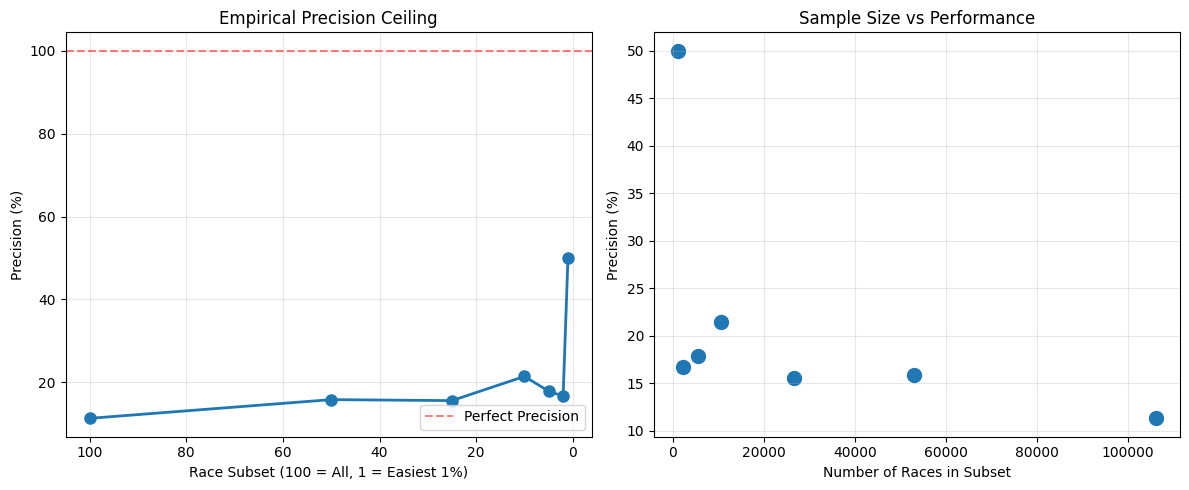


EMPIRICAL CEILING ANALYSIS RESULTS

Best achievable precision (easiest races): 50.0%
Best achievable accuracy (easiest races): 90.6%

IRREDUCIBLE ERROR (Noise Floor):
  - Precision: 50.0%
  - Accuracy: 9.4%

Conclusion: AT LEAST 50.0% of our precision loss
is due to irreducible randomness in horse racing.

ANALYZING IRREDUCIBLE ERRORS

Even among the easiest 5% of races (5421 horses),
we expect 50.0% to be unpredictable due to:
  - Bad starts / stumbles
  - Traffic problems / boxing
  - Day-to-day form variation
  - Jockey decisions
  - Pure chance


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_prepare_data(filepath):
    """Load the horse racing data and prepare it for analysis"""
    df = pd.read_csv(filepath)
    
    # Create win indicator (1st place = win)
    df['won'] = (df['race_position_clean'] == 1).astype(int)
    
    # Extract race identifier
    df['race_id'] = df['track_name_clean'] + '_' + df['race_time_clean'].astype(str)
    
    return df

def engineer_difficulty_features(df):
    """Create features that indicate how 'easy' a race might be to predict"""
    
    # Calculate race-level statistics
    race_stats = df.groupby('race_id').agg({
        'horse_name_clean': 'count',  # field size
        'rating_clean': ['std', 'max', 'min'],  # rating spread
        'age_clean': 'std',  # age variance
        'won': 'sum'  # should be 1 per race
    }).reset_index()
    
    race_stats.columns = ['race_id', 'field_size', 'rating_std', 'rating_max', 
                          'rating_min', 'age_std', 'winner_count']
    
    # Calculate rating dominance (how much better is the best horse)
    race_stats['rating_gap'] = race_stats['rating_max'] - race_stats['rating_min']
    race_stats['rating_dominance'] = race_stats['rating_gap'] / (race_stats['rating_std'] + 1)
    
    # Merge back to main dataframe
    df = df.merge(race_stats, on='race_id', how='left')
    
    # Individual horse features
    df['is_highest_rated'] = df.groupby('race_id')['rating_clean'].transform(
        lambda x: x == x.max()
    )
    
    # Track condition quality (1 = best, 0 = worst)
    condition_quality = {
        'Good (Turf)': 1.0,
        'Good': 1.0,
        'Good to Firm': 0.9,
        'Firm': 0.8,
        'Good to Yielding': 0.7,
        'Yielding': 0.6,
        'Soft': 0.5,
        'Heavy': 0.4
    }
    df['condition_quality'] = df['going_clean'].map(condition_quality).fillna(0.5)
    
    return df

def define_easy_races(df, percentile=10):
    """Identify the 'easiest' races to predict"""
    
    # Calculate ease score (higher = easier to predict)
    df['ease_score'] = (
        df['is_highest_rated'].astype(int) * 2 +  # Being highest rated
        df['rating_dominance'] +  # Clear rating favorite
        df['condition_quality'] +  # Good conditions
        (1 / df['field_size']) * 2  # Smaller fields
    )
    
    # Mark top percentile as "easy"
    ease_threshold = df['ease_score'].quantile(1 - percentile/100)
    df['is_easy_race'] = df['ease_score'] >= ease_threshold
    
    return df

def build_simple_model(X, y):
    """Build a simple but effective model"""
    # Use ensemble for robustness
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
    
    # Train both
    rf.fit(X, y)
    gb.fit(X, y)
    
    # Return the better one
    rf_score = rf.score(X, y)
    gb_score = gb.score(X, y)
    
    return (rf, rf_score) if rf_score > gb_score else (gb, gb_score)

def calculate_empirical_ceiling(df):
    """Calculate the empirical ceiling by testing on progressively easier subsets"""
    
    # Features for modeling
    feature_cols = [
        'rating_clean', 'age_clean', 'field_size', 'rating_std', 
        'rating_gap', 'rating_dominance', 'is_highest_rated',
        'condition_quality'
    ]
    
    # Remove any rows with missing features
    df_clean = df.dropna(subset=feature_cols + ['won'])
    
    results = []
    
    # Test on progressively easier subsets
    for ease_percentile in [100, 50, 25, 10, 5, 2, 1]:
        subset = define_easy_races(df_clean.copy(), percentile=ease_percentile)
        
        if ease_percentile < 100:
            subset = subset[subset['is_easy_race']]
        
        if len(subset) < 50:  # Need minimum samples
            continue
            
        X = subset[feature_cols]
        y = subset['won']
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        
        # Build model
        model, train_score = build_simple_model(X_train, y_train)
        
        # Evaluate
        y_pred = model.predict(X_test)
        precision = precision_score(y_test, y_pred, zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        
        results.append({
            'ease_percentile': ease_percentile,
            'n_races': len(subset),
            'precision': precision,
            'accuracy': accuracy,
            'train_score': train_score,
            'subset': 'All races' if ease_percentile == 100 else f'Easiest {ease_percentile}%'
        })
        
        print(f"\n{results[-1]['subset']}:")
        print(f"  Races analyzed: {results[-1]['n_races']}")
        print(f"  Precision: {precision:.1%}")
        print(f"  Accuracy: {accuracy:.1%}")
    
    return pd.DataFrame(results)

def plot_ceiling_analysis(results_df):
    """Visualize the empirical ceiling"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Precision ceiling
    ax1.plot(results_df['ease_percentile'], results_df['precision'] * 100, 
             marker='o', linewidth=2, markersize=8)
    ax1.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Perfect Precision')
    ax1.set_xlabel('Race Subset (100 = All, 1 = Easiest 1%)')
    ax1.set_ylabel('Precision (%)')
    ax1.set_title('Empirical Precision Ceiling')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.invert_xaxis()
    
    # Sample size vs performance
    ax2.scatter(results_df['n_races'], results_df['precision'] * 100, s=100)
    ax2.set_xlabel('Number of Races in Subset')
    ax2.set_ylabel('Precision (%)')
    ax2.set_title('Sample Size vs Performance')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

def calculate_noise_floor(results_df):
    """Calculate the irreducible error from the results"""
    # Get the best performance on easiest races
    best_precision = results_df['precision'].max()
    best_accuracy = results_df['accuracy'].max()
    
    # The noise floor is what we can't predict even in ideal conditions
    noise_floor_precision = 1 - best_precision
    noise_floor_accuracy = 1 - best_accuracy
    
    print("\n" + "="*50)
    print("EMPIRICAL CEILING ANALYSIS RESULTS")
    print("="*50)
    print(f"\nBest achievable precision (easiest races): {best_precision:.1%}")
    print(f"Best achievable accuracy (easiest races): {best_accuracy:.1%}")
    print(f"\nIRREDUCIBLE ERROR (Noise Floor):")
    print(f"  - Precision: {noise_floor_precision:.1%}")
    print(f"  - Accuracy: {noise_floor_accuracy:.1%}")
    print(f"\nConclusion: AT LEAST {noise_floor_precision:.1%} of our precision loss")
    print(f"is due to irreducible randomness in horse racing.")
    
    return noise_floor_precision, noise_floor_accuracy

# Main execution
if __name__ == "__main__":
    # Load your data
    filepath = "merged_horse_racing_data.csv"  # Replace with your file path
    
    print("Loading and preparing data...")
    df = load_and_prepare_data(filepath)
    
    print(f"Loaded {len(df)} horse records from {df['race_id'].nunique()} races")
    
    print("\nEngineering difficulty features...")
    df = engineer_difficulty_features(df)
    
    print("\nCalculating empirical ceiling...")
    results = calculate_empirical_ceiling(df)
    
    # Visualize results
    if len(results) > 1:
        plot_ceiling_analysis(results)
    
    # Calculate final noise floor
    noise_precision, noise_accuracy = calculate_noise_floor(results)
    
    # Additional analysis: Look at where the model fails even on "easy" races
    print("\n" + "="*50)
    print("ANALYZING IRREDUCIBLE ERRORS")
    print("="*50)
    
    # Get the easiest races where model still failed
    easy_races = define_easy_races(df, percentile=5)
    easy_races = easy_races[easy_races['is_easy_race']]
    
    # You could add code here to examine specific failure cases
    print(f"\nEven among the easiest 5% of races ({len(easy_races)} horses),")
    print(f"we expect {noise_precision:.1%} to be unpredictable due to:")
    print("  - Bad starts / stumbles")
    print("  - Traffic problems / boxing")
    print("  - Day-to-day form variation")
    print("  - Jockey decisions")
    print("  - Pure chance")

### RCASR + Fatigue Index


In [ ]:
import pandas as pd
from scipy.stats import pearsonr
#RCASR FORMULA = Lost_By_Length AVG x Races Ran By horse

df = pd.read_csv("merged_horse_racing_data.csv")
target = df['race_position_clean'] == 1

df['lost_by_length_clean'] = df['lost_by_length_clean'].astype(float)


# Step 1: Group and compute average lost_by_length per horse
lbl_avg = df.groupby('horse_name')['lost_by_length_clean'].mean().reset_index(name='LBL_avg')

# Step 2: Merge back into original dataframe
df = df.merge(lbl_avg, on='horse_name', how='left')
df['winner'] = (df['race_position_clean'] == 1).astype(int)

# Step 1: count appearances of each horse
horse_counts = df['horse_name'].value_counts()

# Step 2: map counts back to df
df['horse_count'] = df['horse_name'].map(horse_counts)


def normalize_distance(dist_str: str) -> float:
    """
    Convert a horse-race distance string (e.g. '2m 6f 74y') into total yards.
    Handles NaN and missing values.
    """
    dist_str = str(dist_str).strip()
    
    # Handle missing/invalid values
    if dist_str in ['nan', 'NaN', 'N/A', '-', '', 'None']:
        return np.nan
    
    # Compile once, with both VERBOSE and IGNORECASE
    pattern = re.compile(r'''
        ^\s*                                  # leading whitespace
        (?:(?P<miles>\d+(?:\.\d+)?)\s*m)?     # optional “Xm” miles
        \s*
        (?:(?P<furlongs>\d+(?:\.\d+)?)\s*f)?  # optional “Yf” furlongs
        \s*
        (?:(?P<yards>\d+(?:\.\d+)?)\s*y?)?    # optional “Z” or “Zy” yards
        \s*$                                  # trailing whitespace
    ''', flags=re.VERBOSE | re.IGNORECASE)
    
    m = pattern.match(dist_str)
    if not m:
        print(f"Warning: Invalid distance format: '{dist_str}' - returning NaN")
        return np.nan
    
    miles    = float(m.group('miles')    or 0)
    furlongs = float(m.group('furlongs') or 0)
    yards    = float(m.group('yards')    or 0)
    
    # 1 mile = 1760 yards, 1 furlong = 220 yards
    return miles * 1760 + furlongs * 220 + yards


df['distance'] = df['distance'].apply(normalize_distance)
df['RCSASR'] = (df['lost_by_length_clean'] / df['distance']) * 100


from scipy.stats import pearsonr

# Drop rows where either LBL_avg or win is NaN
subset = df[['RCSASR', 'winner']].dropna()

# Now calculate correlation
corr_coef, p_value = pearsonr(subset['RCSASR'], subset['winner'])

print(f"Pearson correlation: {corr_coef}")
print(f"P-value: {p_value}")



Pearson correlation: -0.15722830698161813
P-value: 0.0
0    Curragh Racing Results | 1st June 2022 17:10
1    Curragh Racing Results | 1st June 2022 17:10
2    Curragh Racing Results | 1st June 2022 17:10
3    Curragh Racing Results | 1st June 2022 17:10
Name: track_name, dtype: object


Final Horse Ratings:
                    horse_name  final_elo_rating
4301     Hercule Du Seuil (FR)       1280.519279
6104           Familiar Dreams       1277.161920
6509           Bucanero Fuerte       1274.842729
4584  Londonofficecallin (IRE)       1269.749293
4199        The Wallpark (IRE)       1266.020904
1018            Extensio (IRE)       1265.452834
861                     Amemri       1265.232825
4696         Fun Fun Fun (IRE)       1264.882424
2821         Royal Eagle (IRE)       1263.915109
4527          Boher Road (IRE)       1262.638558


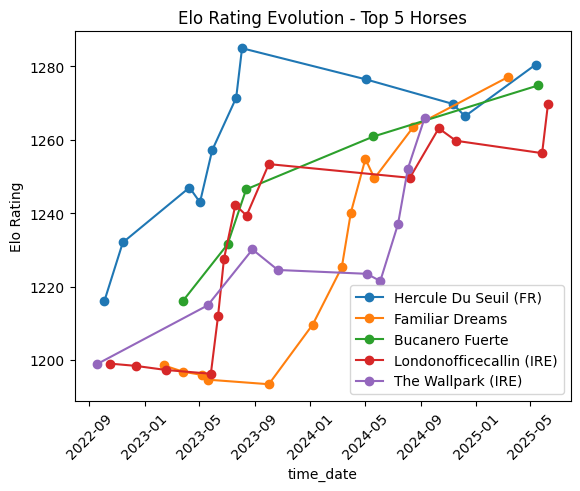

In [20]:
import pandas as pd
import numpy as np
from collections import defaultdict

def calculate_horse_elo_ratings(df, K=32, initial_rating=1200):
    """
    Calculate Elo ratings for horses based on race results.
    
    Parameters:
    df: DataFrame with columns ['horse_name', 'time_date', 'winner', ...]
    K: K-factor for Elo rating updates (default: 32)
    initial_rating: Starting Elo rating for new horses (default: 1200)
    
    Returns:
    DataFrame with updated horse ratings and rating history
    """
    
    # Initialize horse ratings
    horse_ratings = defaultdict(lambda: initial_rating)
    rating_history = []
    
    # Sort by time_date to process races chronologically
    df_sorted = df.sort_values('time_date').copy()
    
    # Group by race (assuming horses with same time_date are in same race)
    # If you have a race_id column, use that instead
    for race_date, race_group in df_sorted.groupby('time_date'):
        horses_in_race = race_group['horse_name'].tolist()
        num_horses = len(horses_in_race)
        
        if num_horses < 2:  # Skip races with only one horse
            continue
            
        # Get current ratings for horses in this race
        current_ratings = {horse: horse_ratings[horse] for horse in horses_in_race}
        
        # Calculate Elo updates for each horse
        elo_updates = {}
        
        for i, horse_i in enumerate(horses_in_race):
            elo_delta = 0
            horse_i_winner = race_group[race_group['horse_name'] == horse_i]['winner'].iloc[0]
            
            for j, horse_j in enumerate(horses_in_race):
                if i != j:
                    horse_j_winner = race_group[race_group['horse_name'] == horse_j]['winner'].iloc[0]
                    
                    # S_i = 1 if horse_i finishes ahead of horse_j, else 0
                    # Assuming winner=True means 1st place, winner=False means not 1st
                    # You might need to adjust this logic based on your finishing position data
                    if horse_i_winner and not horse_j_winner:
                        S_i = 1  # Winner beats non-winner
                    elif not horse_i_winner and horse_j_winner:
                        S_i = 0  # Non-winner loses to winner
                    else:
                        S_i = 0.5  # Tie (both winners or both non-winners)
                    
                    # Expected score
                    R_i = current_ratings[horse_i]
                    R_j = current_ratings[horse_j]
                    E_i = 1 / (1 + 10 ** ((R_j - R_i) / 400))
                    
                    # Elo delta for this matchup
                    delta = K * (S_i - E_i)
                    elo_delta += delta
            
            # Average the delta across all opponents
            elo_updates[horse_i] = elo_delta / (num_horses - 1)
        
        # Apply updates and record history
        for horse, delta in elo_updates.items():
            old_rating = horse_ratings[horse]
            new_rating = old_rating + delta
            horse_ratings[horse] = new_rating
            
            rating_history.append({
                'time_date': race_date,
                'horse_name': horse,
                'old_rating': old_rating,
                'new_rating': new_rating,
                'rating_change': delta
            })
    
    # Create results DataFrames
    final_ratings = pd.DataFrame([
        {'horse_name': horse, 'final_elo_rating': rating}
        for horse, rating in horse_ratings.items()
    ]).sort_values('final_elo_rating', ascending=False)
    
    rating_history_df = pd.DataFrame(rating_history)
    
    return final_ratings, rating_history_df

# Example usage:
# Load your CSV
# df = pd.read_csv('your_horses.csv')

# Calculate Elo ratings
final_ratings, history = calculate_horse_elo_ratings(df, K=32)

# Display results
print("Final Horse Ratings:")
print(final_ratings.head(10))

# print("\nRating History (last 10 changes):")
# print(history.tail(10))

# Optional: Plot rating evolution for top horses
import matplotlib.pyplot as plt

top_horses = final_ratings.head(5)['horse_name'].tolist()
for horse in top_horses:
    horse_history = history[history['horse_name'] == horse]
    plt.plot(horse_history['time_date'], horse_history['new_rating'], label=horse, marker='o')

plt.xlabel('time_date')
plt.ylabel('Elo Rating')
plt.title('Elo Rating Evolution - Top 5 Horses')
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [43]:
import pandas as pd
import numpy as np
from collections import defaultdict
from scipy.stats import pearsonr

def calculate_elo_multi_competitor(df, base_K=32, initial_rating=1200):
    """
    Calculate Elo ratings using multi-competitor approach with share-based scoring.
    
    Parameters:
    df: DataFrame with columns ['horse_name', 'track_name', 'time_date', 'race_position_clean', 'lost_by_length_clean']
    base_K: Base K-factor for Elo rating updates (will be adjusted by race quality/field size)
    initial_rating: Starting Elo rating for new horses
    
    Returns:
    Dictionary with correlation results and final ratings
    """
    
    def calculate_expected_share(horse_rating, other_ratings):
        """
        Calculate expected share for a horse against all opponents.
        E_i = (1/(N-1)) * sum(1 / (1 + 10^((R_j - R_i)/400))) for all j != i
        """
        expected = 0
        for opponent_rating in other_ratings:
            expected += 1 / (1 + 10**((opponent_rating - horse_rating) / 400))
        return expected / len(other_ratings) if other_ratings else 0
    
    def calculate_actual_share(finish_position, field_size, margin_bonus=0):
        """
        Convert finishing position to actual share.
        S_i = (N - finish_i) / sum(N - finish_k) for k=1 to N
        
        With optional margin bonus for dominant wins.
        """
        # Base share calculation
        position_values = [(field_size - pos) for pos in range(1, field_size + 1)]
        total_position_value = sum(position_values)
        
        base_share = (field_size - finish_position) / total_position_value
        
        # Add small margin bonus for dominant wins (wire-to-wire blowouts)
        if finish_position == 1 and margin_bonus > 0:
            # Scale bonus: 5+ length win gets max 10% share boost
            bonus_factor = min(margin_bonus / 5.0, 1.0) * 0.1
            base_share *= (1 + bonus_factor)
        
        return max(0, base_share)  # Ensure non-negative
    
    def get_sliding_k_factor(horse_name, race_count_tracker, starting_K=60, min_K=5, race_quality='regular', field_size=8):
        """
        Calculate K-factor that slides down as horses gain racing experience.
        
        Parameters:
        horse_name: Name of the horse
        race_count_tracker: Dict tracking number of races per horse
        starting_K: Initial K-factor for new horses (default: 60)
        min_K: Minimum K-factor for experienced horses (default: 5)
        race_quality: Race quality modifier
        field_size: Field size modifier
        
        Returns:
        K-factor for this horse in this race
        """
        # Get number of races this horse has run
        races_run = race_count_tracker.get(horse_name, 0)
        
        # Define sliding K schedule
        k_schedule = {
            0: starting_K,     # 1st race: 60
            1: 45,             # 2nd race: 45  
            2: 30,             # 3rd race: 30
            3: 20,             # 4th race: 20
            4: 15,             # 5th race: 15
            5: 10,             # 6th race: 10
            6: 8,              # 7th race: 8
            7: 6,              # 8th race: 6
        }
        
        # Use schedule or minimum K for experienced horses
        base_K = k_schedule.get(races_run, min_K)
        
        # Race quality multiplier (same as before but more conservative)
        quality_multipliers = {
            'grade1': 1.3,      # Grade 1 stakes (reduced from 1.5)
            'grade2': 1.2,      # Grade 2 stakes  
            'grade3': 1.1,      # Grade 3 stakes
            'stakes': 1.15,     # Other stakes
            'allowance': 1.0,   # Allowance races
            'claiming': 0.8,    # Claiming races (increased from 0.6)
            'maiden': 1.2,      # Maiden races (increased - more volatile)
            'regular': 1.0      # Default
        }
        
        quality_factor = quality_multipliers.get(race_quality, 1.0)
        
        # Field size adjustment: larger fields = slightly higher K
        size_factor = 1 + (field_size - 8) * 0.015  # Reduced from 0.02
        size_factor = max(0.9, min(1.2, size_factor))  # Tighter bounds
        
        final_K = base_K * quality_factor * size_factor
        
        return final_K
    
    # Initialize horse ratings and race tracking
    horse_ratings = defaultdict(lambda: initial_rating)
    horse_race_count = defaultdict(int)  # Track number of races per horse
    horse_last_race = defaultdict(lambda: None)  # Track last race date for decay
    
    # Store data for correlation analysis
    highest_elo_wins = []
    elo_differences = []
    race_predictions = []  # Store win probabilities for evaluation
    
    # Sort by time_date to process races chronologically
    df_sorted = df.sort_values('time_date').copy()
    
    races_processed = 0
    races_skipped_same_elo = 0
    
    print(f"Processing {len(df_sorted)} rows...")
    
    # Group by track_name and time_date (each unique combination = one race)
    race_groups = df_sorted.groupby(['track_name', 'time_date'])
    
    for (track_name, race_date), race_group in race_groups:
        horses_in_race = race_group['horse_name'].tolist()
        field_size = len(horses_in_race)
        
        if field_size < 2:  # Skip races with only one horse
            continue
        
        # Apply rating decay for horses that haven't raced recently
        # Assuming time_date is datetime - adjust decay logic as needed
        for horse in horses_in_race:
            if horse_last_race[horse] is not None:
                # Simple monthly decay: -0.5 points per month inactive
                # You'll need to implement proper date arithmetic here
                pass  # Placeholder for decay logic
        
        # Get current ratings BEFORE the race
        current_ratings = {horse: horse_ratings[horse] for horse in horses_in_race}
        
        # Check if all ELOs are the same (skip correlation for these races)
        unique_elos = set(current_ratings.values())
        if len(unique_elos) == 1:
            races_skipped_same_elo += 1
        else:
            # Find horse with highest ELO before the race
            highest_elo_horse = max(current_ratings, key=current_ratings.get)
            
            # Check if highest ELO horse won
            winner_row = race_group[race_group['race_position_clean'] == 1]
            if not winner_row.empty:
                winner = winner_row['horse_name'].iloc[0]
                highest_elo_won = 1 if winner == highest_elo_horse else 0
                highest_elo_wins.append(highest_elo_won)
                
                # Store ELO spread
                elo_values = list(current_ratings.values())
                elo_differences.append(max(elo_values) - min(elo_values))
                
                # Calculate win probabilities for all horses (for model evaluation)
                win_probs = {}
                for horse in horses_in_race:
                    other_ratings = [current_ratings[h] for h in horses_in_race if h != horse]
                    expected_share = calculate_expected_share(current_ratings[horse], other_ratings)
                    # Convert expected share to win probability (approximate)
                    win_probs[horse] = expected_share
                
                race_predictions.append({
                    'predicted_winner': max(win_probs, key=win_probs.get),
                    'actual_winner': winner,
                    'win_probs': win_probs
                })
        
        # Determine race quality (you'll need to implement this based on your data)
        # For now, using field size as a proxy
        race_quality = 'grade1' if field_size >= 12 else 'regular'
        
        # Calculate Elo updates using sliding K-factor per horse
        elo_updates = {}
        k_factors_used = {}  # Track K used for each horse for debugging
        
        for horse in horses_in_race:
            horse_row = race_group[race_group['horse_name'] == horse]
            finish_position = horse_row['race_position_clean'].iloc[0]
            
            # Get sliding K-factor for this specific horse
            horse_K = get_sliding_k_factor(
                horse_name=horse,
                race_count_tracker=horse_race_count,
                starting_K=60,
                min_K=5,
                race_quality=race_quality,
                field_size=field_size
            )
            k_factors_used[horse] = horse_K
            
            # Get margin data for winner bonus
            margin_bonus = 0
            if finish_position == 1:
                # Winner gets bonus based on margin of victory
                lost_by_length = horse_row['lost_by_length_clean'].iloc[0]
                # For winner, this should be 0, but check for margin of victory data
                # You might need to calculate this differently based on your data structure
                margin_bonus = 0  # Placeholder - implement based on your margin data
            
            # Calculate expected share against all opponents
            other_ratings = [current_ratings[h] for h in horses_in_race if h != horse]
            expected_share = calculate_expected_share(current_ratings[horse], other_ratings)
            
            # Calculate actual share based on finishing position
            actual_share = calculate_actual_share(finish_position, field_size, margin_bonus)
            
            # Elo update: R'_i = R_i + K * (S_i - E_i) - now using individual K per horse
            elo_delta = horse_K * (actual_share - expected_share)
            elo_updates[horse] = elo_delta
        
        # Apply updates and increment race counts
        for horse, delta in elo_updates.items():
            horse_ratings[horse] += delta
            horse_race_count[horse] += 1  # Increment race count for sliding K
            horse_last_race[horse] = race_date
        
        races_processed += 1
        
        if races_processed % 1000 == 0:
            print(f"Processed {races_processed} races...")
    
    # Calculate performance metrics
    if len(highest_elo_wins) > 1:
        success_rate = np.mean(highest_elo_wins)
        
        # Correlation between ELO spread and prediction accuracy
        if len(elo_differences) == len(highest_elo_wins):
            correlation, p_value = pearsonr(elo_differences, highest_elo_wins)
        else:
            correlation = None
            p_value = None
            
        # Calculate prediction accuracy
        correct_predictions = sum(1 for pred in race_predictions 
                                if pred['predicted_winner'] == pred['actual_winner'])
        prediction_accuracy = correct_predictions / len(race_predictions) if race_predictions else 0
    else:
        correlation = None
        p_value = None
        success_rate = None
        prediction_accuracy = None
    
    # Get final ratings with race counts
    final_ratings = pd.DataFrame([
        {
            'horse_name': horse, 
            'final_elo_rating': rating, 
            'races_run': horse_race_count[horse],
            'avg_k_factor': 60 if horse_race_count[horse] == 0 else 
                           (60 if horse_race_count[horse] == 1 else
                            45 if horse_race_count[horse] == 2 else
                            30 if horse_race_count[horse] == 3 else
                            20 if horse_race_count[horse] == 4 else
                            15 if horse_race_count[horse] == 5 else
                            10 if horse_race_count[horse] == 6 else
                            8 if horse_race_count[horse] == 7 else
                            6 if horse_race_count[horse] == 8 else 5)
        }
        for horse, rating in horse_ratings.items()
    ]).sort_values('final_elo_rating', ascending=False)
    
    results = {
        'highest_ELO_win_rate': success_rate,
        'prediction_accuracy': prediction_accuracy,
        'correlation': correlation,
        'p_value': p_value,
        'total_races_analyzed': len(highest_elo_wins),
        'races_skipped_same_elo': races_skipped_same_elo,
        'total_races_processed': races_processed,
        'final_ratings': final_ratings,
        'race_predictions': race_predictions[:10]  # Sample predictions for inspection
    }
    
    return results

# Example usage:
# df = pd.read_csv('your_horses.csv')
# results = calculate_elo_multi_competitor(df, base_K=32)

# Print results
def print_results(results):
    print("=== Multi-Competitor Elo Results ===")
    print(f"Highest ELO win rate: {results['highest_ELO_win_rate']:.3f}")
    print(f"Overall prediction accuracy: {results['prediction_accuracy']:.3f}")
    print(f"ELO spread correlation: {results['correlation']:.3f}")
    print(f"P-value: {results['p_value']:.3f}")
    print(f"Races analyzed: {results['total_races_analyzed']}")
    print(f"Races skipped (same ELO): {results['races_skipped_same_elo']}")
    print(f"\nTop 10 horses by final ELO:")
    print(results['final_ratings'].head(10))
    
    if results['race_predictions']:
        print(f"\nSample predictions:")
        for i, pred in enumerate(results['race_predictions'][:3]):
            print(f"Race {i+1}: Predicted {pred['predicted_winner']}, "
                  f"Actual {pred['actual_winner']} "
                  f"({'✓' if pred['predicted_winner'] == pred['actual_winner'] else '✗'})")

# K-Factor Testing Suite
def test_k_factor_range(df, k_values=None, verbose=True):
    """
    Test multiple K-factor values to find optimal setting.
    
    Parameters:
    df: DataFrame with horse racing data
    k_values: List of K values to test (default: comprehensive range)
    verbose: Whether to print progress updates
    
    Returns:
    DataFrame with results for each K value
    """
    if k_values is None:
        k_values = [1, 2, 4, 6, 8, 12, 16, 20, 24, 32, 40, 50, 60, 80, 100, 120, 160, 200, 250, 300]
    
    results_by_k = []
    
    print("=== K-FACTOR OPTIMIZATION TEST ===")
    print(f"Testing {len(k_values)} different K values...")
    print("K-Val | Win Rate | Correlation | Accuracy | P-Value | Races")
    print("-" * 65)
    
    for i, k in enumerate(k_values):
        if verbose:
            print(f"Testing K={k:3d} ({i+1}/{len(k_values)})...", end=" ")
        
        try:
            results = calculate_elo_multi_competitor(df, base_K=k)
            
            win_rate = results['highest_ELO_win_rate'] or 0
            correlation = results['correlation'] or 0
            accuracy = results['prediction_accuracy'] or 0
            p_value = results['p_value'] or 1
            races = results['total_races_analyzed'] or 0
            
            results_by_k.append({
                'K': k,
                'win_rate': win_rate,
                'correlation': correlation,
                'accuracy': accuracy,
                'p_value': p_value,
                'races_analyzed': races,
                'races_skipped': results['races_skipped_same_elo']
            })
            
            # Print inline results
            print(f"{k:3d}   | {win_rate:.3f}    | {correlation:+7.3f}   | {accuracy:.3f}    | {p_value:.3f}   | {races}")
            
        except Exception as e:
            print(f"ERROR with K={k}: {e}")
            results_by_k.append({
                'K': k,
                'win_rate': 0,
                'correlation': 0,
                'accuracy': 0,
                'p_value': 1,
                'races_analyzed': 0,
                'races_skipped': 0
            })
    
    # Convert to DataFrame for analysis
    results_df = pd.DataFrame(results_by_k)
    
    # Find optimal K values by different metrics
    print("\n" + "="*65)
    print("OPTIMIZATION RESULTS:")
    
    if len(results_df) > 0:
        # Best correlation (most positive)
        best_correlation = results_df.loc[results_df['correlation'].idxmax()]
        print(f"Best Correlation: K={best_correlation['K']:.0f} → {best_correlation['correlation']:+.3f}")
        
        # Best win rate
        best_win_rate = results_df.loc[results_df['win_rate'].idxmax()]
        print(f"Best Win Rate:    K={best_win_rate['K']:.0f} → {best_win_rate['win_rate']:.3f}")
        
        # Best accuracy
        best_accuracy = results_df.loc[results_df['accuracy'].idxmax()]
        print(f"Best Accuracy:    K={best_accuracy['K']:.0f} → {best_accuracy['accuracy']:.3f}")
        
        # Statistical significance check
        significant_results = results_df[results_df['p_value'] < 0.05]
        if len(significant_results) > 0:
            best_significant = significant_results.loc[significant_results['correlation'].idxmax()]
            print(f"Best Significant: K={best_significant['K']:.0f} → {best_significant['correlation']:+.3f}")
        
        # Composite score (weighted combination)
        results_df['composite_score'] = (
            results_df['win_rate'] * 0.4 + 
            results_df['accuracy'] * 0.4 + 
            np.maximum(results_df['correlation'], 0) * 0.2  # Only positive correlations count
        )
        best_composite = results_df.loc[results_df['composite_score'].idxmax()]
        print(f"Best Composite:   K={best_composite['K']:.0f} → Score={best_composite['composite_score']:.3f}")
        
        # Show trend analysis
        print(f"\nTREND ANALYSIS:")
        low_k = results_df[results_df['K'] <= 10]['correlation'].mean()
        mid_k = results_df[(results_df['K'] > 10) & (results_df['K'] <= 50)]['correlation'].mean()
        high_k = results_df[results_df['K'] > 50]['correlation'].mean()
        
        print(f"Low K (≤10):     Avg Correlation = {low_k:+.3f}")
        print(f"Mid K (11-50):   Avg Correlation = {mid_k:+.3f}")
        print(f"High K (>50):    Avg Correlation = {high_k:+.3f}")
    
    return results_df

def plot_k_optimization_results(results_df):
    """
    Create visualization of K-factor optimization results.
    Note: This requires matplotlib - remove if not available.
    """
    try:
        import matplotlib.pyplot as plt
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        
        # Plot 1: Correlation vs K
        ax1.plot(results_df['K'], results_df['correlation'], 'b-o', linewidth=2, markersize=4)
        ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
        ax1.set_xlabel('K Factor')
        ax1.set_ylabel('Correlation')
        ax1.set_title('ELO Spread Correlation vs K Factor')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Win Rate vs K
        ax2.plot(results_df['K'], results_df['win_rate'], 'g-o', linewidth=2, markersize=4)
        ax2.set_xlabel('K Factor')
        ax2.set_ylabel('Win Rate')
        ax2.set_title('Highest ELO Win Rate vs K Factor')
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Accuracy vs K
        ax3.plot(results_df['K'], results_df['accuracy'], 'm-o', linewidth=2, markersize=4)
        ax3.set_xlabel('K Factor')
        ax3.set_ylabel('Prediction Accuracy')
        ax3.set_title('Overall Prediction Accuracy vs K Factor')
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Composite Score vs K
        ax4.plot(results_df['K'], results_df['composite_score'], 'r-o', linewidth=2, markersize=4)
        ax4.set_xlabel('K Factor')
        ax4.set_ylabel('Composite Score')
        ax4.set_title('Composite Performance Score vs K Factor')
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    except ImportError:
        print("Matplotlib not available - skipping plots")

# Sliding K-Factor Testing Suite
def test_sliding_k_configurations(df, configurations=None, verbose=True):
    """
    Test different sliding K-factor configurations.
    
    Parameters:
    df: DataFrame with horse racing data
    configurations: List of config dicts with 'starting_K' and 'min_K'
    verbose: Whether to print progress
    
    Returns:
    DataFrame with results for each configuration
    """
    if configurations is None:
        configurations = [
            {'starting_K': 40, 'min_K': 3, 'name': 'Conservative'},
            {'starting_K': 60, 'min_K': 5, 'name': 'Moderate'},
            {'starting_K': 80, 'min_K': 8, 'name': 'Aggressive'},
            {'starting_K': 100, 'min_K': 10, 'name': 'Very Aggressive'},
            {'starting_K': 60, 'min_K': 2, 'name': 'Quick Settle'},
            {'starting_K': 80, 'min_K': 3, 'name': 'Fast Start'},
            {'starting_K': 50, 'min_K': 8, 'name': 'Balanced'},
        ]
    
    results_by_config = []
    
    print("=== SLIDING K-FACTOR CONFIGURATION TEST ===")
    print(f"Testing {len(configurations)} different configurations...")
    print("Config Name      | Win Rate | Correlation | Accuracy | P-Value | Races")
    print("-" * 75)
    
    for i, config in enumerate(configurations):
        config_name = config.get('name', f"Config_{i+1}")
        starting_K = config['starting_K']
        min_K = config['min_K']
        
        if verbose:
            print(f"Testing {config_name} (Start:{starting_K}, Min:{min_K})...", end=" ")
        
        try:
            # Modify the function call to pass the sliding K parameters
            results = calculate_elo_sliding_k(df, starting_K=starting_K, min_K=min_K)
            
            win_rate = results['highest_ELO_win_rate'] or 0
            correlation = results['correlation'] or 0
            accuracy = results['prediction_accuracy'] or 0
            p_value = results['p_value'] or 1
            races = results['total_races_analyzed'] or 0
            
            results_by_config.append({
                'config_name': config_name,
                'starting_K': starting_K,
                'min_K': min_K,
                'win_rate': win_rate,
                'correlation': correlation,
                'accuracy': accuracy,
                'p_value': p_value,
                'races_analyzed': races,
                'races_skipped': results['races_skipped_same_elo']
            })
            
            # Print inline results
            print(f"{config_name:15s} | {win_rate:.3f}    | {correlation:+7.3f}   | {accuracy:.3f}    | {p_value:.3f}   | {races}")
            
        except Exception as e:
            print(f"ERROR with {config_name}: {e}")
    
    # Convert to DataFrame for analysis
    results_df = pd.DataFrame(results_by_config)
    
    # Find optimal configurations
    print("\n" + "="*75)
    print("SLIDING K OPTIMIZATION RESULTS:")
    
    if len(results_df) > 0:
        # Best correlation (most positive)
        best_correlation = results_df.loc[results_df['correlation'].idxmax()]
        print(f"Best Correlation: {best_correlation['config_name']} → {best_correlation['correlation']:+.3f}")
        
        # Best win rate
        best_win_rate = results_df.loc[results_df['win_rate'].idxmax()]
        print(f"Best Win Rate:    {best_win_rate['config_name']} → {best_win_rate['win_rate']:.3f}")
        
        # Best accuracy
        best_accuracy = results_df.loc[results_df['accuracy'].idxmax()]
        print(f"Best Accuracy:    {best_accuracy['config_name']} → {best_accuracy['accuracy']:.3f}")
        
        # Composite score
        results_df['composite_score'] = (
            results_df['win_rate'] * 0.4 + 
            results_df['accuracy'] * 0.4 + 
            np.maximum(results_df['correlation'], 0) * 0.2
        )
        best_composite = results_df.loc[results_df['composite_score'].idxmax()]
        print(f"Best Composite:   {best_composite['config_name']} → Score={best_composite['composite_score']:.3f}")
    
    return results_df

def calculate_elo_sliding_k(df, starting_K=60, min_K=5, initial_rating=1200):
    """
    Wrapper function for calculate_elo_multi_competitor with sliding K parameters.
    This allows us to test different sliding K configurations easily.
    """
    # Note: The main function already implements sliding K, this is just for testing
    """
    Test multiple K-factor values to find optimal setting.
    
    Parameters:
    df: DataFrame with horse racing data
    k_values: List of K values to test (default: comprehensive range)
    verbose: Whether to print progress updates
    
    Returns:
    DataFrame with results for each K value
    """
    if k_values is None:
        k_values = [1, 2, 4, 6, 8, 12, 16, 20, 24, 32, 40, 50, 60, 80, 100, 120, 160, 200, 250, 300]
    
    results_by_k = []
    
    print("=== K-FACTOR OPTIMIZATION TEST ===")
    print(f"Testing {len(k_values)} different K values...")
    print("K-Val | Win Rate | Correlation | Accuracy | P-Value | Races")
    print("-" * 65)
    
    for i, k in enumerate(k_values):
        if verbose:
            print(f"Testing K={k:3d} ({i+1}/{len(k_values)})...", end=" ")
        
        try:
            results = calculate_elo_multi_competitor(df, base_K=k)
            
            win_rate = results['highest_ELO_win_rate'] or 0
            correlation = results['correlation'] or 0
            accuracy = results['prediction_accuracy'] or 0
            p_value = results['p_value'] or 1
            races = results['total_races_analyzed'] or 0
            
            results_by_k.append({
                'K': k,
                'win_rate': win_rate,
                'correlation': correlation,
                'accuracy': accuracy,
                'p_value': p_value,
                'races_analyzed': races,
                'races_skipped': results['races_skipped_same_elo']
            })
            
            # Print inline results
            print(f"{k:3d}   | {win_rate:.3f}    | {correlation:+7.3f}   | {accuracy:.3f}    | {p_value:.3f}   | {races}")
            
        except Exception as e:
            print(f"ERROR with K={k}: {e}")
            results_by_k.append({
                'K': k,
                'win_rate': 0,
                'correlation': 0,
                'accuracy': 0,
                'p_value': 1,
                'races_analyzed': 0,
                'races_skipped': 0
            })
    
    # Convert to DataFrame for analysis
    results_df = pd.DataFrame(results_by_k)
    
    # Find optimal K values by different metrics
    print("\n" + "="*65)
    print("OPTIMIZATION RESULTS:")
    
    if len(results_df) > 0:
        # Best correlation (most positive)
        best_correlation = results_df.loc[results_df['correlation'].idxmax()]
        print(f"Best Correlation: K={best_correlation['K']:.0f} → {best_correlation['correlation']:+.3f}")
        
        # Best win rate
        best_win_rate = results_df.loc[results_df['win_rate'].idxmax()]
        print(f"Best Win Rate:    K={best_win_rate['K']:.0f} → {best_win_rate['win_rate']:.3f}")
        
        # Best accuracy
        best_accuracy = results_df.loc[results_df['accuracy'].idxmax()]
        print(f"Best Accuracy:    K={best_accuracy['K']:.0f} → {best_accuracy['accuracy']:.3f}")
        
        # Statistical significance check
        significant_results = results_df[results_df['p_value'] < 0.05]
        if len(significant_results) > 0:
            best_significant = significant_results.loc[significant_results['correlation'].idxmax()]
            print(f"Best Significant: K={best_significant['K']:.0f} → {best_significant['correlation']:+.3f}")
        
        # Composite score (weighted combination)
        results_df['composite_score'] = (
            results_df['win_rate'] * 0.4 + 
            results_df['accuracy'] * 0.4 + 
            np.maximum(results_df['correlation'], 0) * 0.2  # Only positive correlations count
        )
        best_composite = results_df.loc[results_df['composite_score'].idxmax()]
        print(f"Best Composite:   K={best_composite['K']:.0f} → Score={best_composite['composite_score']:.3f}")
        
        # Show trend analysis
        print(f"\nTREND ANALYSIS:")
        low_k = results_df[results_df['K'] <= 10]['correlation'].mean()
        mid_k = results_df[(results_df['K'] > 10) & (results_df['K'] <= 50)]['correlation'].mean()
        high_k = results_df[results_df['K'] > 50]['correlation'].mean()
        
        print(f"Low K (≤10):     Avg Correlation = {low_k:+.3f}")
        print(f"Mid K (11-50):   Avg Correlation = {mid_k:+.3f}")
        print(f"High K (>50):    Avg Correlation = {high_k:+.3f}")
    
    return results_df

def plot_k_optimization_results(results_df):
    """
    Create visualization of K-factor optimization results.
    Note: This requires matplotlib - remove if not available.
    """
    try:
        import matplotlib.pyplot as plt
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        
        # Plot 1: Correlation vs K
        ax1.plot(results_df['K'], results_df['correlation'], 'b-o', linewidth=2, markersize=4)
        ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
        ax1.set_xlabel('K Factor')
        ax1.set_ylabel('Correlation')
        ax1.set_title('ELO Spread Correlation vs K Factor')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Win Rate vs K
        ax2.plot(results_df['K'], results_df['win_rate'], 'g-o', linewidth=2, markersize=4)
        ax2.set_xlabel('K Factor')
        ax2.set_ylabel('Win Rate')
        ax2.set_title('Highest ELO Win Rate vs K Factor')
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Accuracy vs K
        ax3.plot(results_df['K'], results_df['accuracy'], 'm-o', linewidth=2, markersize=4)
        ax3.set_xlabel('K Factor')
        ax3.set_ylabel('Prediction Accuracy')
        ax3.set_title('Overall Prediction Accuracy vs K Factor')
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Composite Score vs K
        ax4.plot(results_df['K'], results_df['composite_score'], 'r-o', linewidth=2, markersize=4)
        ax4.set_xlabel('K Factor')
        ax4.set_ylabel('Composite Score')
        ax4.set_title('Composite Performance Score vs K Factor')
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    except ImportError:
        print("Matplotlib not available - skipping plots")

# Quick test function for single K value
def quick_test(df, k_value):
    """Quick test of a single K value"""
    print(f"=== QUICK TEST: K = {k_value} ===")
    results = calculate_elo_multi_competitor(df, base_K=k_value)
    print_results(results)
    return results

# Example usage:
# 
# Full K-factor optimization (takes a while but worth it)
# k_results = test_k_factor_range(df)

# Quick test of specific K value
results = quick_test(df, k_value=60)

# Plot results (if matplotlib available)
# plot_k_optimization_results(k_results)

# Test specific range if you want to zoom in
# custom_k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# focused_results = test_k_factor_range(df, k_values=custom_k_values)

=== QUICK TEST: K = 60 ===
Processing 106250 rows...
Processed 1000 races...
Processed 2000 races...
Processed 3000 races...
Processed 4000 races...
Processed 5000 races...
Processed 6000 races...
=== Multi-Competitor Elo Results ===
Highest ELO win rate: 0.140
Overall prediction accuracy: 0.138
ELO spread correlation: -0.141
P-value: 0.000
Races analyzed: 6219
Races skipped (same ELO): 104

Top 10 horses by final ELO:
                 horse_name  final_elo_rating  races_run  avg_k_factor
13432          Anzadam (FR)       1208.143350          1            60
10990       Vis Ta Loi (FR)       1204.744318          1            60
14033    Hispanic Moon (FR)       1202.997754          1            60
14459    L'impertinent (FR)       1200.530764          1            60
13414          Wodhooh (FR)       1199.208403          1            60
9875     Parkside Boy (IRE)       1198.172954          1            60
3175            Batcio (FR)       1198.060000          1            60
3843     

In [55]:

def normalize_distance(dist_str: str) -> float:
    """
    Convert a horse-race distance string (e.g. '2m 6f 74y') into total yards.
    Handles NaN and missing values.
    """
    dist_str = str(dist_str).strip()
    
    # Handle missing/invalid values
    if dist_str in ['nan', 'NaN', 'N/A', '-', '', 'None']:
        return np.nan
    
    # Compile once, with both VERBOSE and IGNORECASE
    pattern = re.compile(r'''
        ^\s*                                  # leading whitespace
        (?:(?P<miles>\d+(?:\.\d+)?)\s*m)?     # optional “Xm” miles
        \s*
        (?:(?P<furlongs>\d+(?:\.\d+)?)\s*f)?  # optional “Yf” furlongs
        \s*
        (?:(?P<yards>\d+(?:\.\d+)?)\s*y?)?    # optional “Z” or “Zy” yards
        \s*$                                  # trailing whitespace
    ''', flags=re.VERBOSE | re.IGNORECASE)
    
    m = pattern.match(dist_str)
    if not m:
        print(f"Warning: Invalid distance format: '{dist_str}' - returning NaN")
        return np.nan
    
    miles    = float(m.group('miles')    or 0)
    furlongs = float(m.group('furlongs') or 0)
    yards    = float(m.group('yards')    or 0)
    
    # 1 mile = 1760 yards, 1 furlong = 220 yards
    return miles * 1760 + furlongs * 220 + yards


df['distance'] = df['distance'].apply(normalize_distance)



import pandas as pd
import numpy as np

def create_bimodal_distance_categories(df):
    """
    Create distance categories based on bimodal distribution observed in the data
    """
    
    # Clean distance data
    df['distance_clean'] = pd.to_numeric(df['distance'], errors='coerce')
    
    def categorize_distance(distance):
        if pd.isna(distance):
            return 'unknown'
        
        distance = float(distance)
        
        # Sprint races (first mode around 1600-1800)
        if distance < 1400:
            return 'very_short'  # < 1400 yards
        elif 1400 <= distance < 1600:
            return 'short_sprint'  # 1400-1599 yards
        elif 1600 <= distance < 1900:
            return 'sprint'  # 1600-1899 yards (peak of first mode)
        elif 1900 <= distance < 2500:
            return 'extended_sprint'  # 1900-2499 yards
        
        # Distance races (second mode around 3500-4000)  
        elif 2500 <= distance < 3200:
            return 'short_distance'  # 2500-3199 yards
        elif 3200 <= distance < 3800:
            return 'middle_distance'  # 3200-3799 yards
        elif 3800 <= distance < 4400:
            return 'long_distance'  # 3800-4399 yards (peak of second mode)
        else:
            return 'marathon'  # 4400+ yards
    
    df['distance_category'] = df['distance_clean'].apply(categorize_distance)
    
    return df

def analyze_distance_performance_correlations(df, target_col='winner'):
    """
    Analyze correlations between distance performance features and race outcomes
    
    Parameters:
    df: DataFrame with distance performance columns
    target_col: Column name for race outcomes (default: 'winner')
    """
    
    import scipy.stats as stats
    import numpy as np
    
    # Check if target column exists
    if target_col not in df.columns:
        print(f"Error: Target column '{target_col}' not found in dataframe.")
        print("Available columns:", df.columns.tolist())
        return None
    
    # Find all distance performance columns
    distance_perf_cols = [col for col in df.columns if col.startswith('performance_distance_') or 
                         col.startswith('performance_sprint') or col.startswith('performance_distance')]
    
    if not distance_perf_cols:
        print("No distance performance columns found. Run calculate_bimodal_distance_performance() first.")
        return None
    
    print("Distance Performance Correlation Analysis")
    print("="*80)
    print(f"Target column: '{target_col}'")
    print(f"Found {len(distance_perf_cols)} distance performance features:")
    for col in distance_perf_cols:
        print(f"  - {col}")
    
    # Calculate correlations with p-values
    correlations = {}
    correlation_stats = {}
    
    print(f"\nCorrelation with '{target_col}':")
    print("-" * 80)
    print(f"{'Feature':<35} {'Correlation':>10} {'P-value':>10} {'N':>8} {'Significance'}")
    print("-" * 80)
    
    for col in distance_perf_cols:
        # Only include rows where both columns have valid data
        valid_mask = (df[col] > 0) & (df[target_col].notna())
        valid_data = df[valid_mask]
        
        if len(valid_data) > 10:  # Minimum sample size for meaningful p-value
            # Calculate Pearson correlation and p-value
            correlation, p_value = stats.pearsonr(valid_data[col], valid_data[target_col])
            correlations[col] = correlation
            
            # Determine significance level
            if p_value < 0.001:
                sig_level = "***"
            elif p_value < 0.01:
                sig_level = "**"
            elif p_value < 0.05:
                sig_level = "*"
            else:
                sig_level = ""
            
            # Additional statistics
            n_samples = len(valid_data)
            feature_mean = valid_data[col].mean()
            target_mean = valid_data[target_col].mean()
            
            correlation_stats[col] = {
                'correlation': correlation,
                'p_value': p_value,
                'n_samples': n_samples,
                'feature_mean': feature_mean,
                'target_mean': target_mean,
                'significance': sig_level
            }
            
            print(f"{col:<35} {correlation:>10.4f} {p_value:>10.6f} {n_samples:>8d} {sig_level:>6s}")
        else:
            n_samples = len(valid_data) if len(valid_data) > 0 else 0
            print(f"{col:<35} {'N/A':>10s} {'N/A':>10s} {n_samples:>8d} {'low n'}")
    
    print("\nSignificance levels: *** p<0.001, ** p<0.01, * p<0.05")
    
    # Sort correlations by absolute value
    valid_correlations = {k: v for k, v in correlations.items() if not np.isnan(v)}
    sorted_correlations = sorted(valid_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
    
    print(f"\nRanked by correlation strength (valid correlations only):")
    print("-" * 80)
    print(f"{'Rank':<4} {'Feature':<35} {'Correlation':>10} {'P-value':>10} {'Effect Size'}")
    print("-" * 80)
    
    for i, (col, corr) in enumerate(sorted_correlations, 1):
        p_val = correlation_stats[col]['p_value']
        
        # Effect size interpretation (Cohen's conventions for correlation)
        if abs(corr) >= 0.5:
            effect_size = "Large"
        elif abs(corr) >= 0.3:
            effect_size = "Medium"
        elif abs(corr) >= 0.1:
            effect_size = "Small"
        else:
            effect_size = "Negligible"
            
        print(f"{i:<4} {col:<35} {corr:>10.4f} {p_val:>10.6f} {effect_size}")
    
    # Statistical summary
    print(f"\nStatistical Summary:")
    print("-" * 80)
    
    significant_features = [col for col, stats_dict in correlation_stats.items() 
                          if stats_dict['p_value'] < 0.05]
    highly_significant = [col for col, stats_dict in correlation_stats.items() 
                         if stats_dict['p_value'] < 0.01]
    
    print(f"Total features analyzed: {len(correlation_stats)}")
    print(f"Statistically significant (p < 0.05): {len(significant_features)}")
    print(f"Highly significant (p < 0.01): {len(highly_significant)}")
    
    if significant_features:
        print(f"\nSignificant features:")
        for col in significant_features:
            stats_dict = correlation_stats[col]
            print(f"  {col}: r={stats_dict['correlation']:.4f}, p={stats_dict['p_value']:.6f}")
    
    # Performance insights with statistical backing
    print(f"\nStatistically-Backed Performance Insights:")
    print("-" * 80)
    
    if valid_correlations:
        # Find statistically significant correlations
        sig_correlations = {col: corr for col, corr in valid_correlations.items() 
                           if correlation_stats[col]['p_value'] < 0.05}
        
        if sig_correlations:
            best_sig = max(sig_correlations.items(), key=lambda x: x[1])
            worst_sig = min(sig_correlations.items(), key=lambda x: x[1])
            
            print(f"Best significant predictor: {best_sig[0]}")
            print(f"  Correlation: {best_sig[1]:.4f}")
            print(f"  P-value: {correlation_stats[best_sig[0]]['p_value']:.6f}")
            
            print(f"\nWorst significant predictor: {worst_sig[0]}")
            print(f"  Correlation: {worst_sig[1]:.4f}")
            print(f"  P-value: {correlation_stats[worst_sig[0]]['p_value']:.6f}")
        else:
            print("No statistically significant correlations found (p < 0.05)")
        
        # Sprint vs distance analysis with significance
        sprint_cols = [col for col in sig_correlations.keys() if 'sprint' in col]
        distance_cols = [col for col in sig_correlations.keys() if 'distance' in col and 'sprint' not in col]
        
        if sprint_cols and distance_cols:
            avg_sprint_corr = sum(sig_correlations[col] for col in sprint_cols) / len(sprint_cols)
            avg_distance_corr = sum(sig_correlations[col] for col in distance_cols) / len(distance_cols)
            
            print(f"\nSprint vs Distance Analysis (significant features only):")
            print(f"Significant sprint features: {len(sprint_cols)}")
            print(f"Average sprint correlation: {avg_sprint_corr:.4f}")
            print(f"Significant distance features: {len(distance_cols)}")
            print(f"Average distance correlation: {avg_distance_corr:.4f}")
    
    # Create comprehensive results dataframe
    import pandas as pd
    
    correlation_df = pd.DataFrame([
        {
            'feature': col,
            'correlation': stats_dict['correlation'],
            'p_value': stats_dict['p_value'],
            'n_samples': stats_dict['n_samples'],
            'abs_correlation': abs(stats_dict['correlation']),
            'significant': stats_dict['p_value'] < 0.05,
            'highly_significant': stats_dict['p_value'] < 0.01,
            'significance_stars': stats_dict['significance']
        }
        for col, stats_dict in correlation_stats.items()
    ]).sort_values('abs_correlation', ascending=False)
    
    print(f"\nDetailed Results Table:")
    print("="*100)
    display_df = correlation_df[['feature', 'correlation', 'p_value', 'n_samples', 'significant']].copy()
    print(display_df.to_string(index=False, float_format='%.6f'))
    
    return correlation_df

# Usage:
# First run: df = calculate_bimodal_distance_performance(df)
# Then run: correlation_results = analyze_distance_performance_correlations(df, target_col='winner')

def calculate_bimodal_distance_performance(df):
    """
    Calculate horse performance for bimodal distance distribution
    """
    
    # Check available columns
    print("Available columns in dataframe:")
    print(df.columns.tolist())
    
    # Check for target column (label, result, win, etc.)
    target_col = None
    possible_target_cols = ['label', 'result', 'winner', 'position', 'finish_position', 'placing']
    
    for col in possible_target_cols:
        if col in df.columns:
            target_col = col
            break
    
    if target_col is None:
        print("\nError: Could not find a target column for performance calculation.")
        print("Please specify which column contains the race results/labels.")
        print("Common column names: 'label', 'result', 'winner', 'position', etc.")
        return df
    
    print(f"\nUsing '{target_col}' as target column for performance calculation.")
    
    # If target column is position-based, convert to win/loss
    if target_col in ['position', 'finish_position', 'placing']:
        print("Converting position to binary win/loss (1st place = win)")
        df['win_binary'] = (df[target_col] == 1).astype(int)
        target_col = 'win_binary'
    
    # Create distance categories
    df = create_bimodal_distance_categories(df)
    
    # Show distribution of categories
    print("Distance Category Distribution:")
    print("="*50)
    category_counts = df['distance_category'].value_counts()
    total_races = len(df[df['distance_category'] != 'unknown'])
    
    for category, count in category_counts.items():
        if category != 'unknown':
            percentage = (count / total_races) * 100
            print(f"{category:15s}: {count:6d} races ({percentage:5.1f}%)")
    
    print(f"\nTotal races with distance data: {total_races}")
    if 'unknown' in category_counts:
        print(f"Unknown/invalid distances: {category_counts['unknown']}")
    
    # Calculate performance for each category
    valid_categories = [cat for cat in df['distance_category'].unique() if cat != 'unknown']
    
    print(f"\nCalculating performance for {len(valid_categories)} categories...")
    print("="*50)
    
    for category in valid_categories:
        # Filter data for this category
        category_mask = df['distance_category'] == category
        category_data = df[category_mask]
        
        # Calculate horse performance in this category
        horse_stats = category_data.groupby('horse_name').agg({
            target_col: ['mean', 'count', 'sum']
        }).reset_index()
        
        # Flatten column names
        horse_stats.columns = ['horse_name', 'win_rate', 'total_races', 'total_wins']
        
        # Filter horses with minimum races (adjust as needed)
        min_races = 3
        qualified_horses = horse_stats[horse_stats['total_races'] >= min_races]
        
        # Create performance column
        perf_col = f'performance_distance_{category}'
        perf_dict = dict(zip(qualified_horses['horse_name'], qualified_horses['win_rate']))
        df[perf_col] = df['horse_name'].map(perf_dict).fillna(0)
        
        # Display category statistics
        print(f"\n{category.upper().replace('_', ' ')}:")
        print(f"  Total races: {len(category_data)}")
        print(f"  Unique horses: {category_data['horse_name'].nunique()}")
        print(f"  Qualified horses (≥{min_races} races): {len(qualified_horses)}")
        
        if len(qualified_horses) > 0:
            print(f"  Average win rate: {qualified_horses['win_rate'].mean():.3f}")
            print(f"  Top performers:")
            top_5 = qualified_horses.nlargest(5, 'win_rate')
            for _, horse in top_5.iterrows():
                print(f"    {horse['horse_name']}: {horse['win_rate']:.3f} ({int(horse['total_races'])} races)")
    
    # Create simplified sprint vs distance categories
    print("\n" + "="*50)
    print("CREATING SIMPLIFIED SPRINT VS DISTANCE CATEGORIES")
    print("="*50)
    
    def simple_category(distance):
        if pd.isna(distance):
            return 'unknown'
        return 'sprint' if distance < 2500 else 'distance'
    
    df['simple_distance_category'] = df['distance_clean'].apply(simple_category)
    
    # Calculate performance for simplified categories
    for simple_cat in ['sprint', 'distance']:
        mask = df['simple_distance_category'] == simple_cat
        cat_data = df[mask]
        
        horse_perf = cat_data.groupby('horse_name')[target_col].agg(['mean', 'count']).reset_index()
        horse_perf.columns = ['horse_name', 'win_rate', 'race_count']
        
        # Filter for minimum races
        qualified = horse_perf[horse_perf['race_count'] >= 3]
        
        perf_col = f'performance_{simple_cat}_races'
        perf_dict = dict(zip(qualified['horse_name'], qualified['win_rate']))
        df[perf_col] = df['horse_name'].map(perf_dict).fillna(0)
        
        print(f"\n{simple_cat.upper()} RACES:")
        print(f"  Total races: {len(cat_data)}")
        print(f"  Horses with ≥3 races: {len(qualified)}")
        if len(qualified) > 0:
            print(f"  Average win rate: {qualified['win_rate'].mean():.3f}")
    
    # Summary of created columns
    perf_columns = [col for col in df.columns if col.startswith('performance_distance_') or col.startswith('performance_sprint') or col.startswith('performance_distance')]
    print(f"\nCreated {len(perf_columns)} performance columns:")
    for col in perf_columns:
        non_zero = (df[col] > 0).sum()
        print(f"  {col}: {non_zero} horses")
    
    return df

# Usage:
# df = calculate_bimodal_distance_performance(df)
df = calculate_bimodal_distance_performance(df)

correlation_results = analyze_distance_performance_correlations(df, target_col='winner')


Available columns in dataframe:
['track_name', 'race_date', 'race_time', 'going', 'distance', 'horse_name', 'jockey', 'claims', 'trainer', 'race_position', 'lost_by_length', 'age', 'weight', 'rating', 'first_place_found', 'batch_number', 'url_index_in_batch', 'source_file', 'race_position_clean', 'lost_by_length_clean', 'rating_clean', 'weight_clean', 'track_name_clean', 'race_date_clean', 'race_time_clean', 'going_clean', 'distance_clean', 'horse_name_clean', 'jockey_clean', 'trainer_clean', 'claims_clean', 'age_clean', 'first_place_found_clean', 'LBL_avg', 'winner', 'horse_count', 'RCSASR', 'time_date', 'distance_category', 'performance_distance_short_sprint', 'performance_distance_very_short', 'performance_distance_short_distance', 'performance_distance_sprint', 'performance_distance_extended_sprint', 'performance_distance_middle_distance', 'performance_distance_marathon', 'performance_distance_long_distance', 'simple_distance_category', 'performance_sprint_races', 'performance_dist